<a href="https://colab.research.google.com/github/tanx1509/tvscredit/blob/main/Tanishq_Sethi_TVS_Credit_Anlaytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TVS CREDIT ANALYTICS_Tanishq Sethi**

**The Challenge:**
In the world of finance, a loan is more than just numbers on a spreadsheet; it's a story of ambition, need, and circumstance. For our client, a mid-sized NBFC, the challenge of recovering overdue loans is not just a financial imperative but a delicate human interaction.

The goal is to revolutionize this process, and we aim to move from a reactive, one-size-fits-all model to a proactive, predictive, and personalized strategy. By harnessing the power of data science and artificial intelligence, we can not only identify customers at risk of default but also understand why they are at risk. This understanding is the key to unlocking more effective and empathetic recovery strategies.

It replaces the traditional, uniform collection method with a proactive, personalized, and AI-driven strategy; to increase efficiency and maintain good customer relationships.

The plan involves four key steps:
1.  **Data Analysis:** Exploring customer data to find patterns in their behavior and demographics.
2.  **Predictive Modeling:** Building a machine learning model to identify customers at risk of defaulting on payments.
3.  **Personalized Strategy:** Creating an engine to recommend tailored collection approaches for different customer profiles.
4.  **Empathetic Communication:** Developing an AI chatbot to interact with customers in a way that suits their individual situation.

**Setup and Data Loading**

We begin with gathering the right tools. We are importing the essential Python libraries that will serve as our toolkit for this analysis. Using pandas for data manipulation, seaborn and matplotlib for creating beautiful visualizations, and scikit-learn, xgboost, and catboost for building our powerful predictive models.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, make_scorer
import joblib
import shap
from tqdm import tqdm
import warnings

# Setting the plot style and ignore warnings for cleaner output
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# uploading the dataset
from google.colab import files
uploaded = files.upload()

# Loading the dataset
try:
    df = pd.read_csv('Analytics_loan_collection_dataset.csv')
    print("Dataset loaded successfully!")
    print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure 'Analytics_loan_collection_dataset.csv' is in the correct directory.")

Saving Analytics_loan_collection_dataset.csv to Analytics_loan_collection_dataset (3).csv
Dataset loaded successfully!
Dataset contains 2000 rows and 19 columns.


***Exploratory Data Analysis (EDA):***

 The goal of Exploratory Data Analysis (EDA) is to understand the existing data visually. We are sifting through the data to uncover clues, patterns, and the subtle stories of the 2,000 customers in this dataset. We're not just looking at numbers; we're looking for the human behaviors behind them.

*The Big Picture:* We start with a high-level overview—checking data quality, understanding the overall default rate, and creating a correlation heatmap to see which factors move together.

*Deep Dive Visualizations:* We then create a gallery of charts to visually compare customers who defaulted against those who didn't. This is where the most powerful insights often emerge. Like:

 How does income affect repayment?

 Are certain loan types riskier?

What is the relationship between missed payments and the length of the delay?

 Initial Data Exploration
Dataset shape: (2000, 19)

Missing values check:
CustomerID             0
Age                    0
Income                 0
Location               0
EmploymentStatus       0
LoanAmount             0
TenureMonths           0
InterestRate           0
LoanType               0
MissedPayments         0
DelaysDays             0
PartialPayments        0
InteractionAttempts    0
SentimentScore         0
ResponseTimeHours      0
AppUsageFrequency      0
WebsiteVisits          0
Complaints             0
Target                 0

Target variable distribution (0 = Paid, 1 = Defaulted):
Target
0    0.508
1    0.492
Name: proportion, dtype: float64

 High-Level Insights
 Overall Default Rate: 49.20%
 Most Common Loan Type: Auto
 Highest Risk Employment Status: Unemployed
 Average Sentiment Score vs. Default:
Target
0    0.034134
1   -0.039878


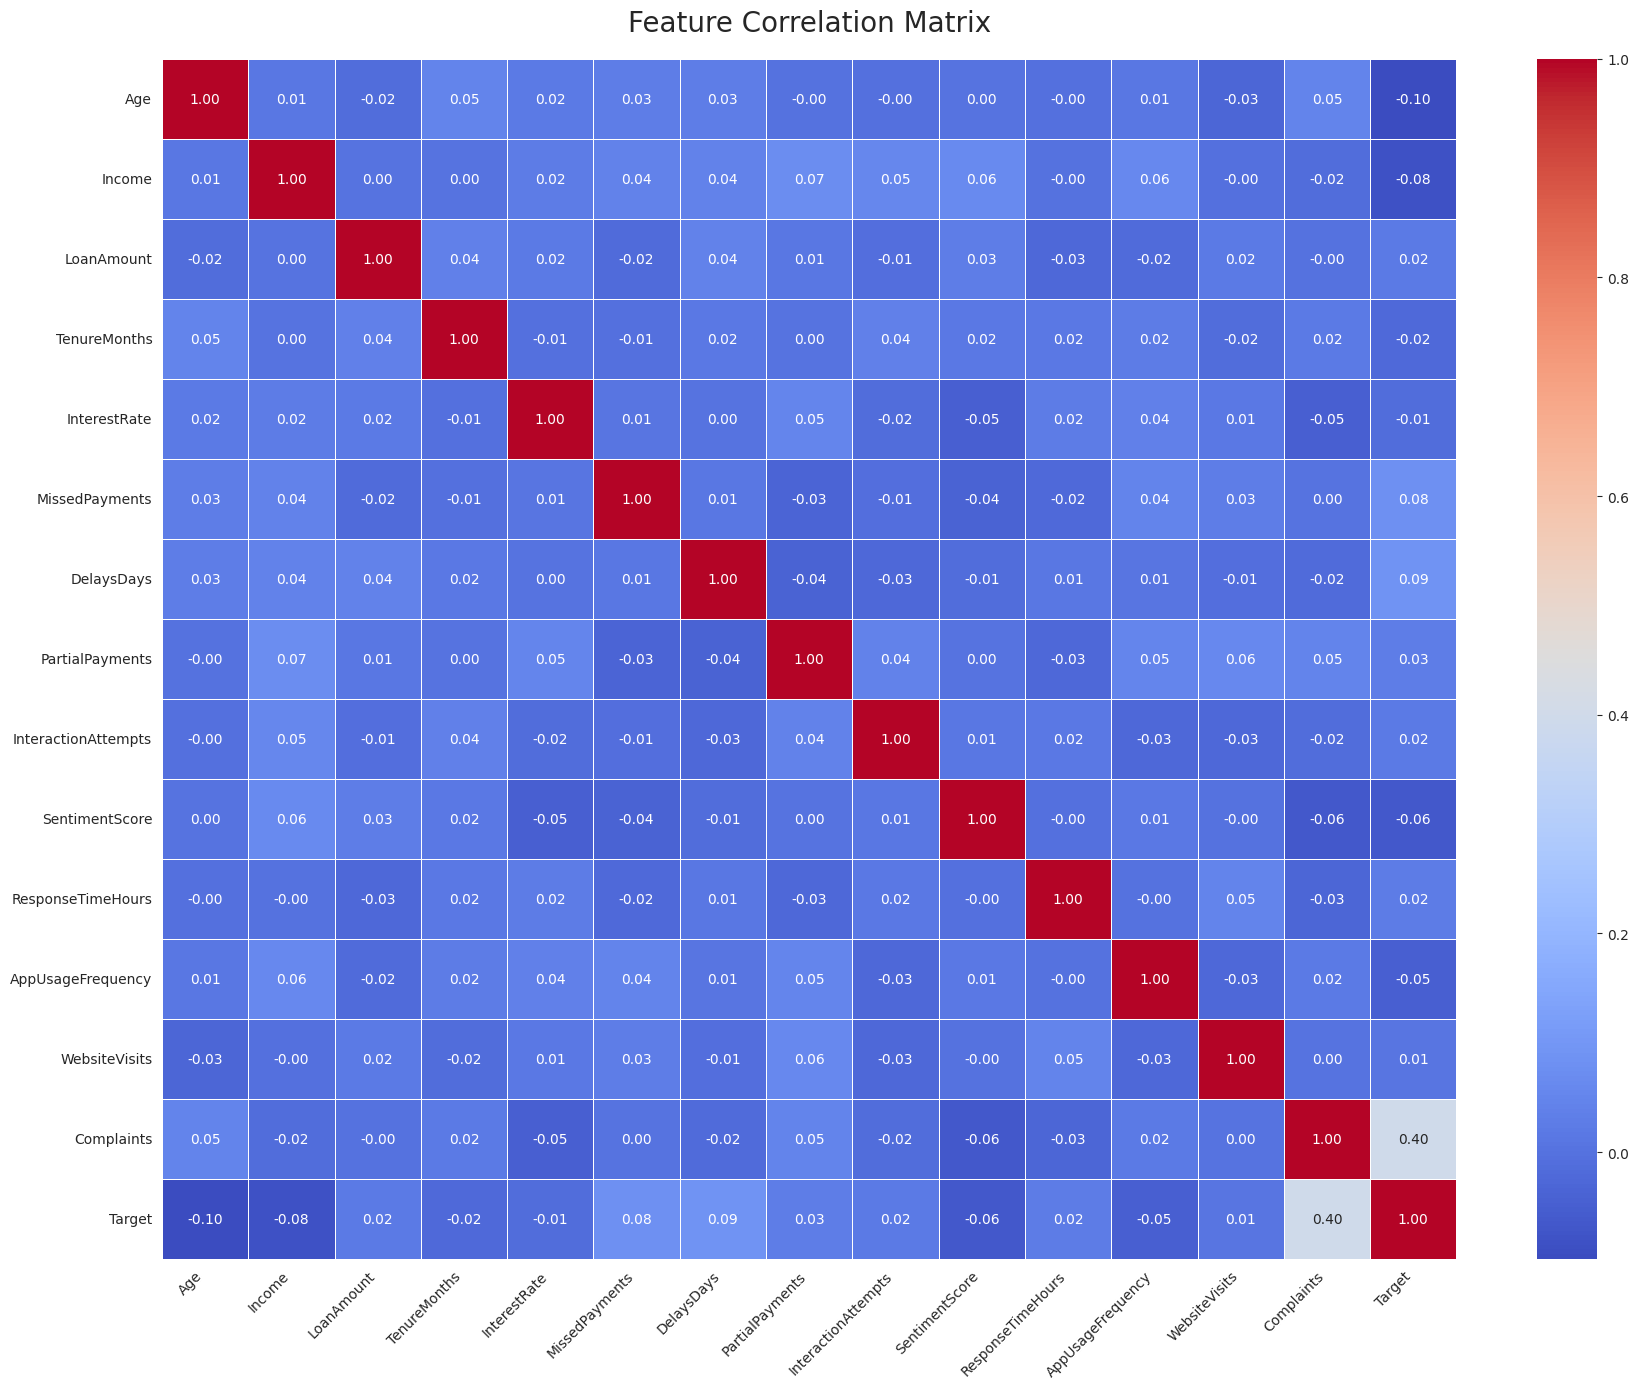

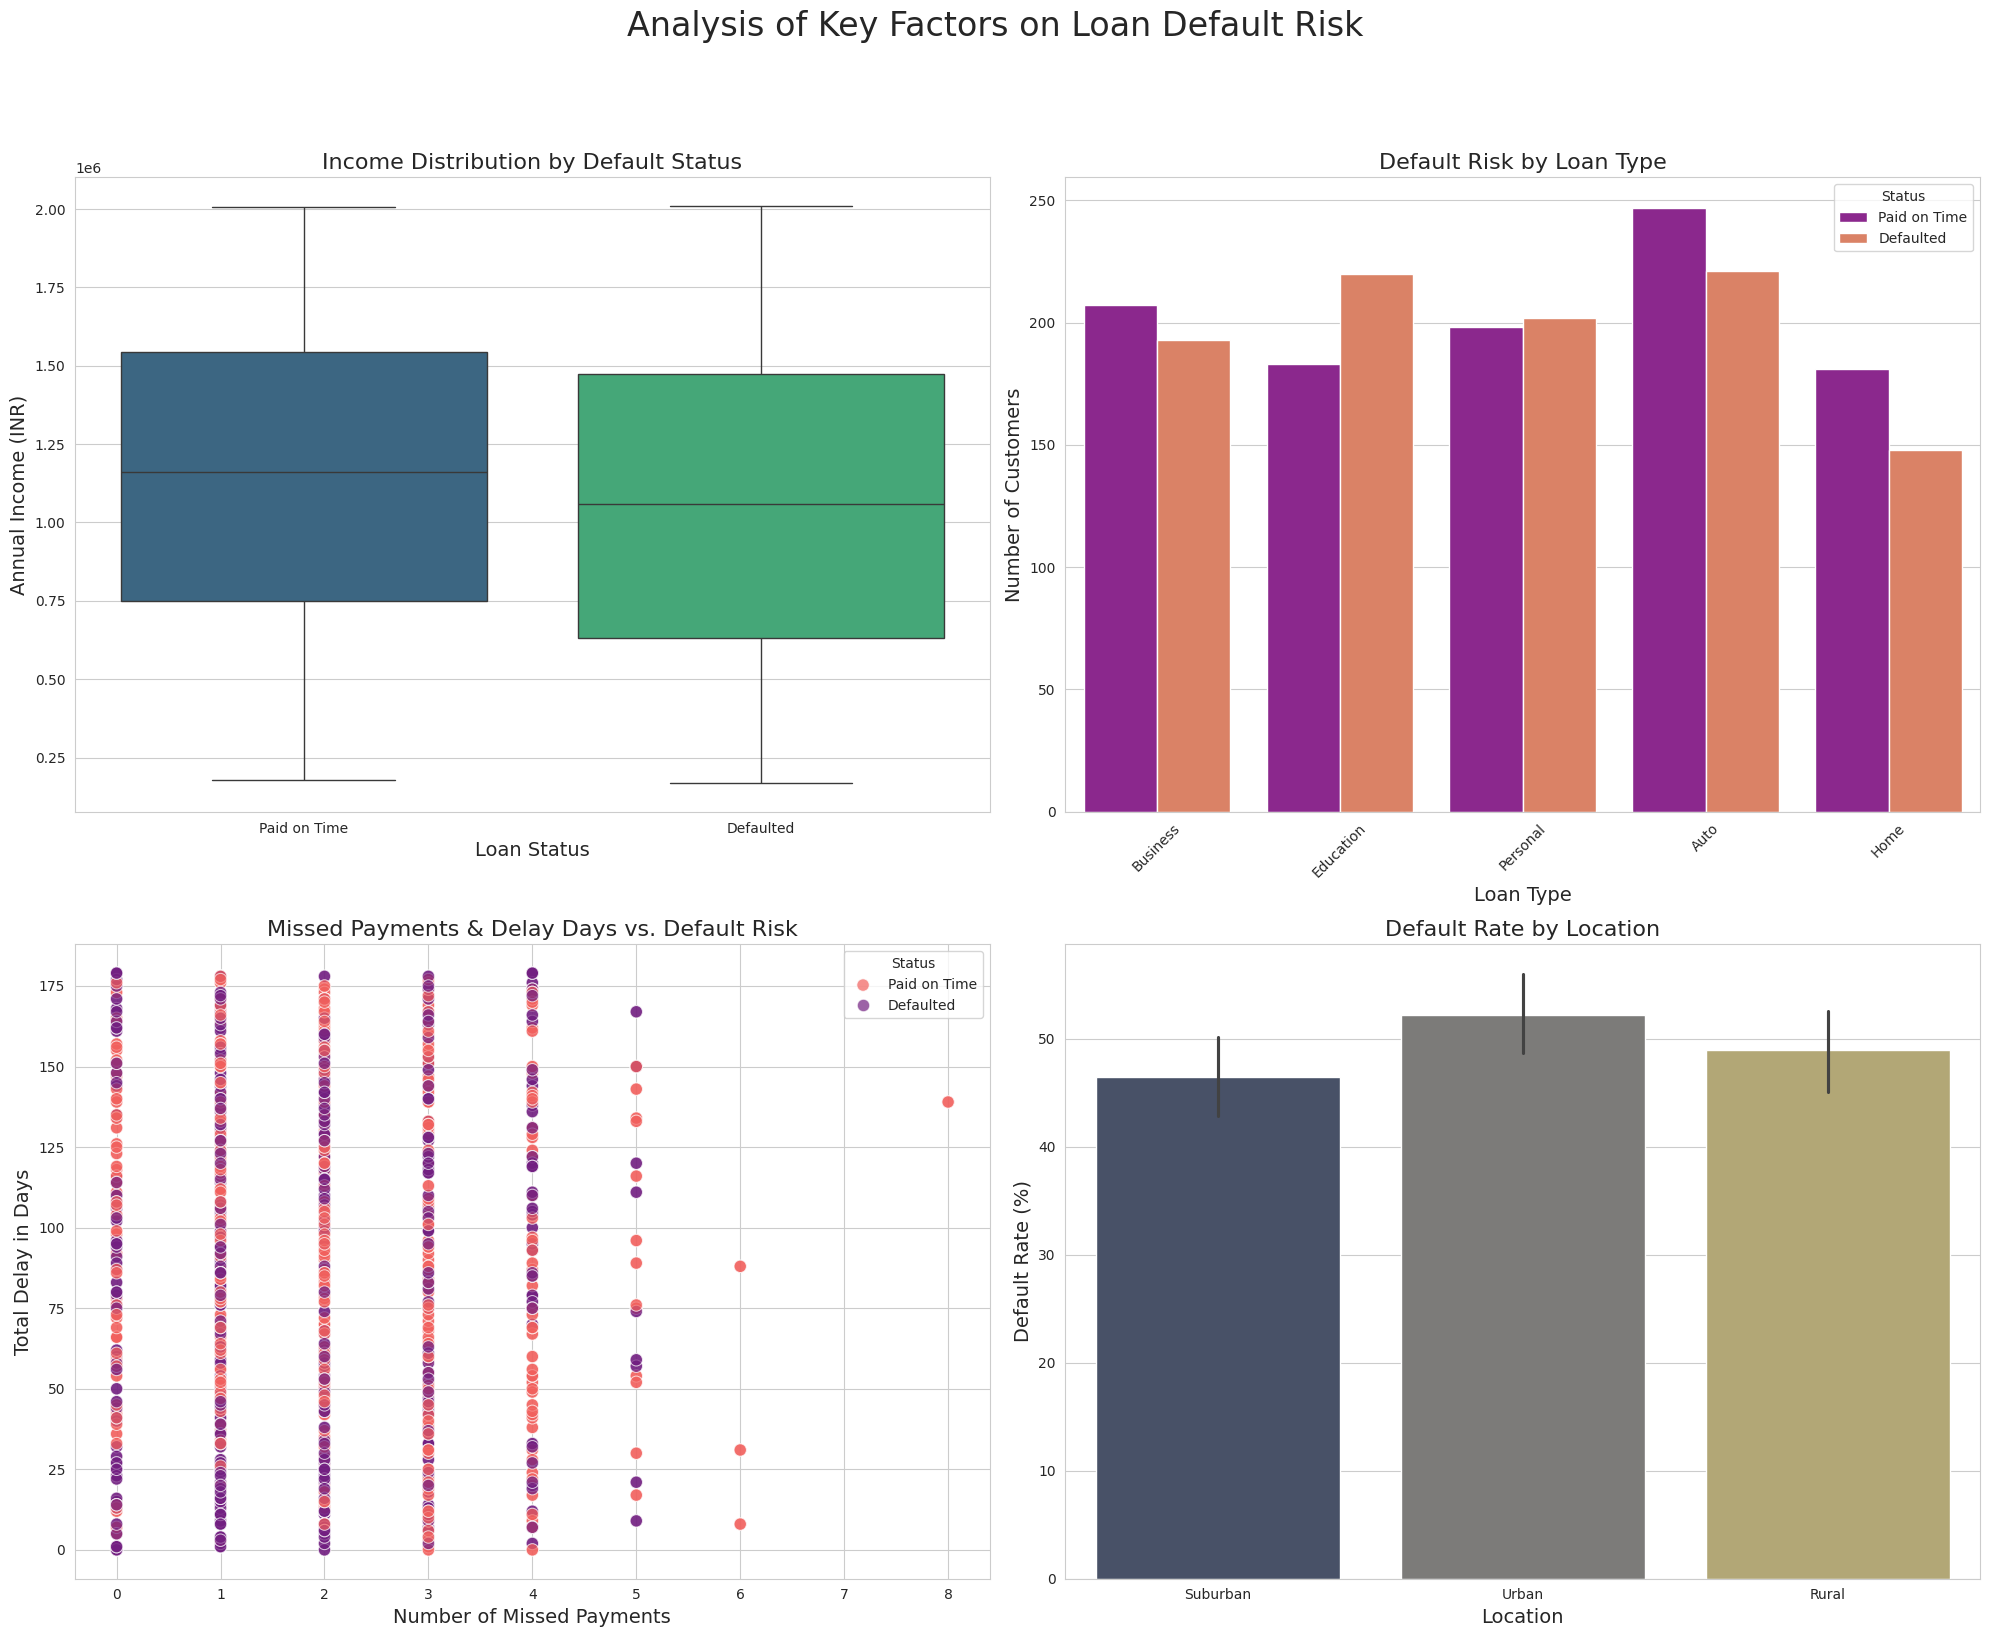

In [ ]:
# Initial Exploration

print(" Initial Data Exploration")
print(f"Dataset shape: {df.shape}")
print(f"\nMissing values check:\n{df.isnull().sum().to_string()}")
print(f"\nTarget variable distribution (0 = Paid, 1 = Defaulted):\n{df['Target'].value_counts(normalize=True)}")

# Key Insights Calculation
default_rate = df['Target'].mean()
common_loan_type = df['LoanType'].mode()[0]
highest_risk_employment = df.groupby('EmploymentStatus')['Target'].mean().idxmax()
sentiment_vs_default = df.groupby('Target')['SentimentScore'].mean()

print("\n High-Level Insights")
print(f" Overall Default Rate: {default_rate:.2%}")
print(f" Most Common Loan Type: {common_loan_type}")
print(f" Highest Risk Employment Status: {highest_risk_employment}")
print(f" Average Sentiment Score vs. Default:\n{sentiment_vs_default.to_string()}")

# Visualizations

# 1. Correlation Matrix
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix', fontsize=20, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Key Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Analysis of Key Factors on Loan Default Risk', fontsize=24, y=1.02)

# Income vs. Default Risk
sns.boxplot(x='Target', y='Income', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Income Distribution by Default Status', fontsize=16)
axes[0, 0].set_xticklabels(['Paid on Time', 'Defaulted'])
axes[0, 0].set_xlabel('Loan Status', fontsize=14)
axes[0, 0].set_ylabel('Annual Income (INR)', fontsize=14)

# Loan Type vs. Default Risk
sns.countplot(x='LoanType', hue='Target', data=df, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Default Risk by Loan Type', fontsize=16)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_xlabel('Loan Type', fontsize=14)
axes[0, 1].set_ylabel('Number of Customers', fontsize=14)
axes[0, 1].legend(title='Status', labels=['Paid on Time', 'Defaulted'])

# Payment Delays vs. Default Risk
sns.scatterplot(x='MissedPayments', y='DelaysDays', hue='Target', data=df, ax=axes[1, 0], palette='magma', alpha=0.7, s=80)
axes[1, 0].set_title('Missed Payments & Delay Days vs. Default Risk', fontsize=16)
axes[1, 0].set_xlabel('Number of Missed Payments', fontsize=14)
axes[1, 0].set_ylabel('Total Delay in Days', fontsize=14)
axes[1, 0].legend(title='Status', labels=['Paid on Time', 'Defaulted'])

# Default Rate by Location
sns.barplot(x='Location', y='Target', data=df, ax=axes[1, 1], palette='cividis', estimator=lambda x: sum(x) / len(x) * 100)
axes[1, 1].set_title('Default Rate by Location', fontsize=16)
axes[1, 1].set_xlabel('Location', fontsize=14)
axes[1, 1].set_ylabel('Default Rate (%)', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Our initial EDA reveals some compelling patterns:

*Pristine Data:* The dataset is complete, with no missing values, providing a solid foundation for our model.

*Balanced Risk:* The customer base is almost evenly split, with about 49% at risk of default. This balance is ideal for training an unbiased model.

*Clear Warning Signs:* The correlation matrix and scatter plot highlight a strong, intuitive relationship: ***the more payments a customer misses and the longer the delay in days, the more likely they are to default.***

*The Human Factor:* Sentiment matters. Customers who are likely to default have, on average, a negative sentiment score,

**Detailed Numerical Feature Analysis**

***Our New Smart Features:***

We are engineering a new set of 'smart' features and then applying a log transformation to normalize their distributions. This step is crucial for helping our machine learning models perform at their best.

*DebtToIncomeRatio:* A classic financial metric. A higher ratio might indicate financial strain.

*RepaymentBehaviorScore:* A weighted score that penalizes missed payments and delays more heavily than partial payments. It's a single number that summarizes a customer's payment reliability.

*InteractionEngagementScore:* This feature tries to capture how engaged a customer is. We reward contact attempts and website visits but penalize negative sentiment.


 Creating Smart Features and Analyzing Distributions

 Engineered features created and log transformations applied.

[Plotting Distributions and Outliers...]


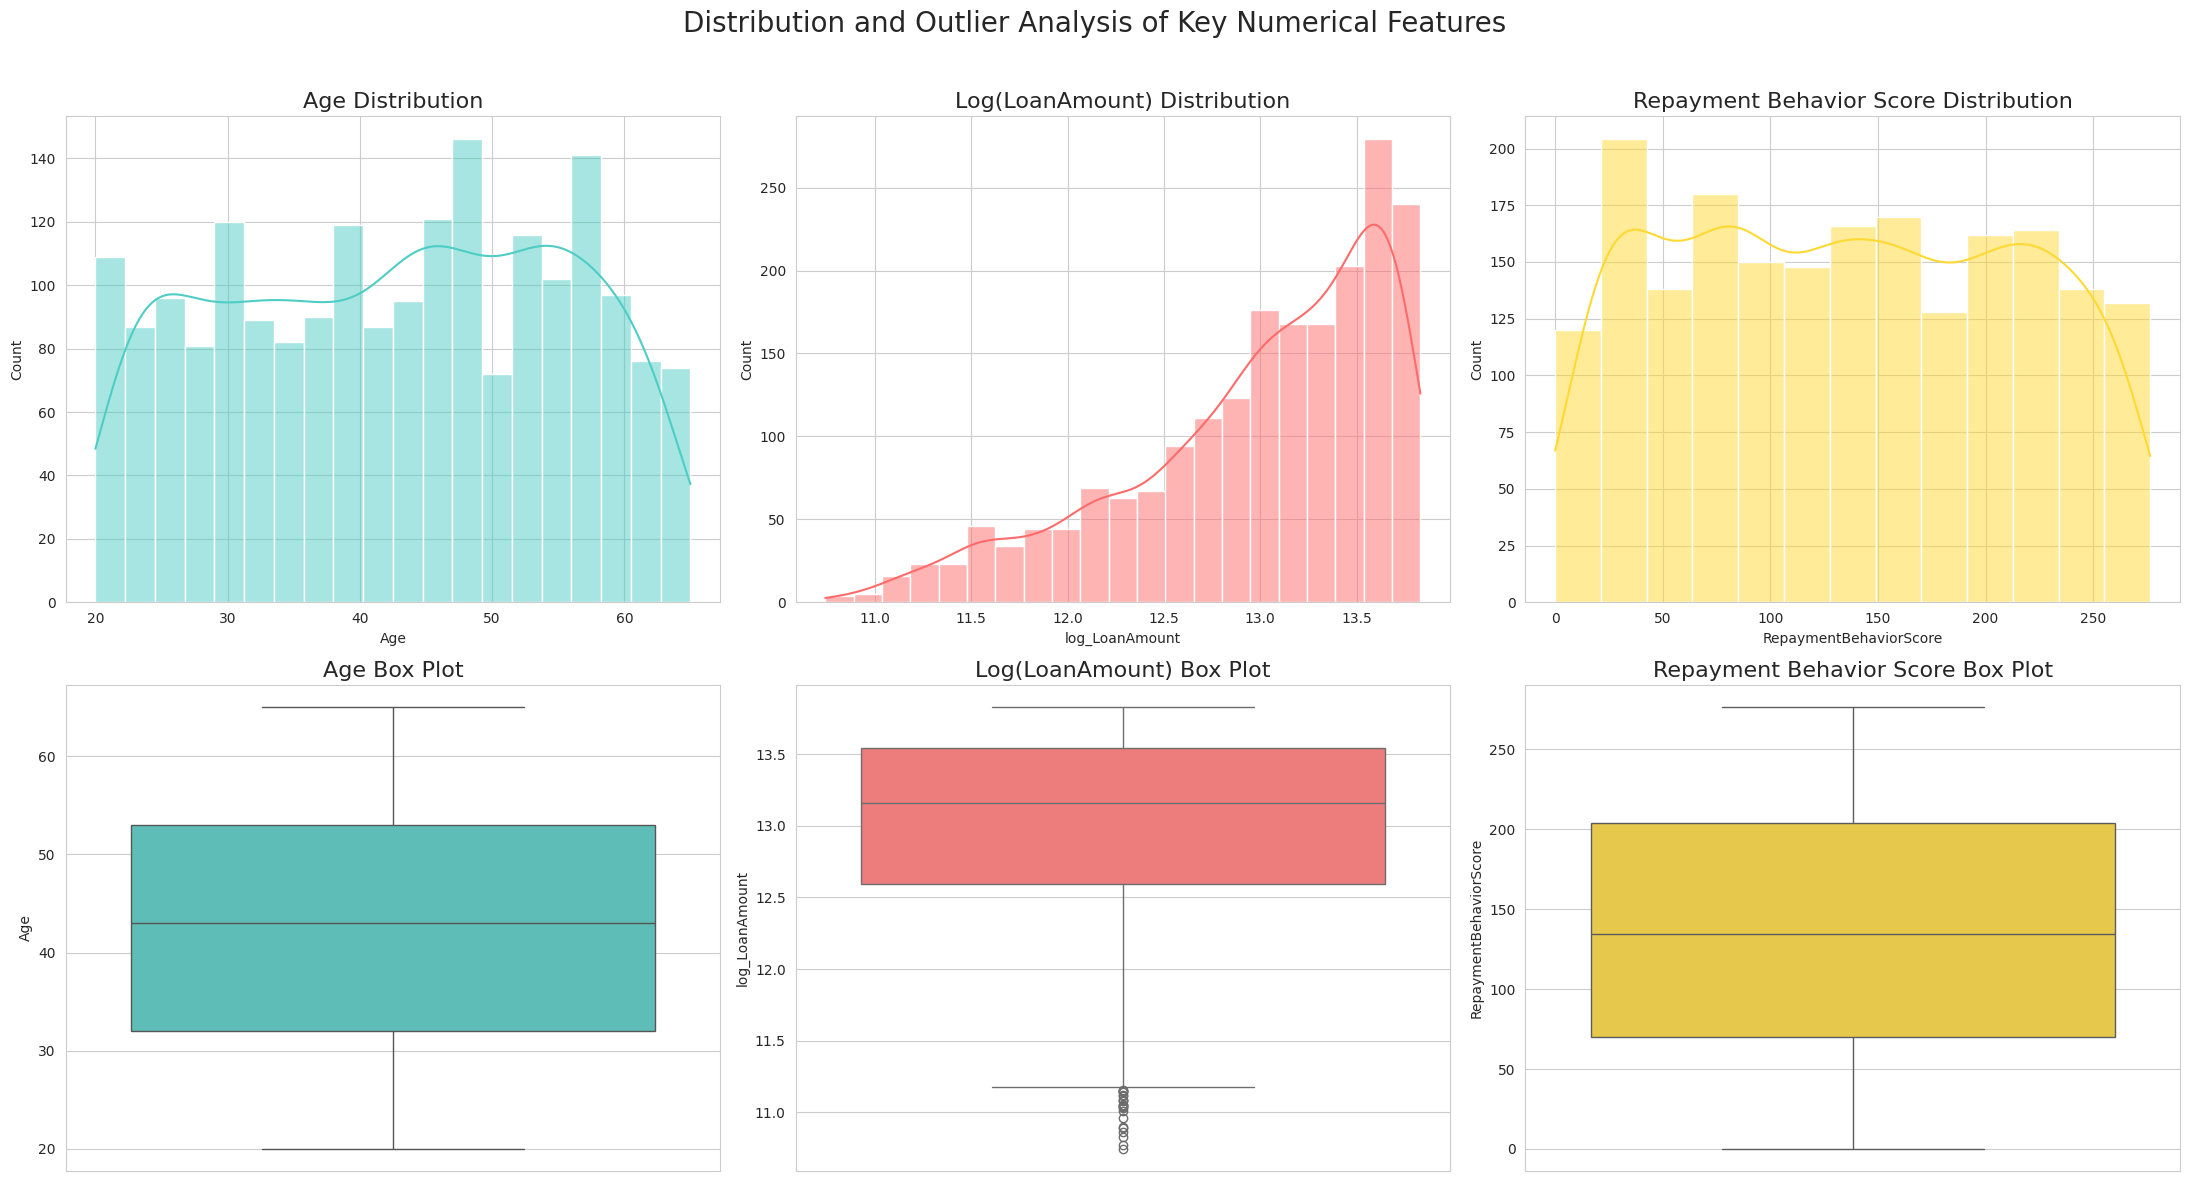


 Advanced Data Visualizations


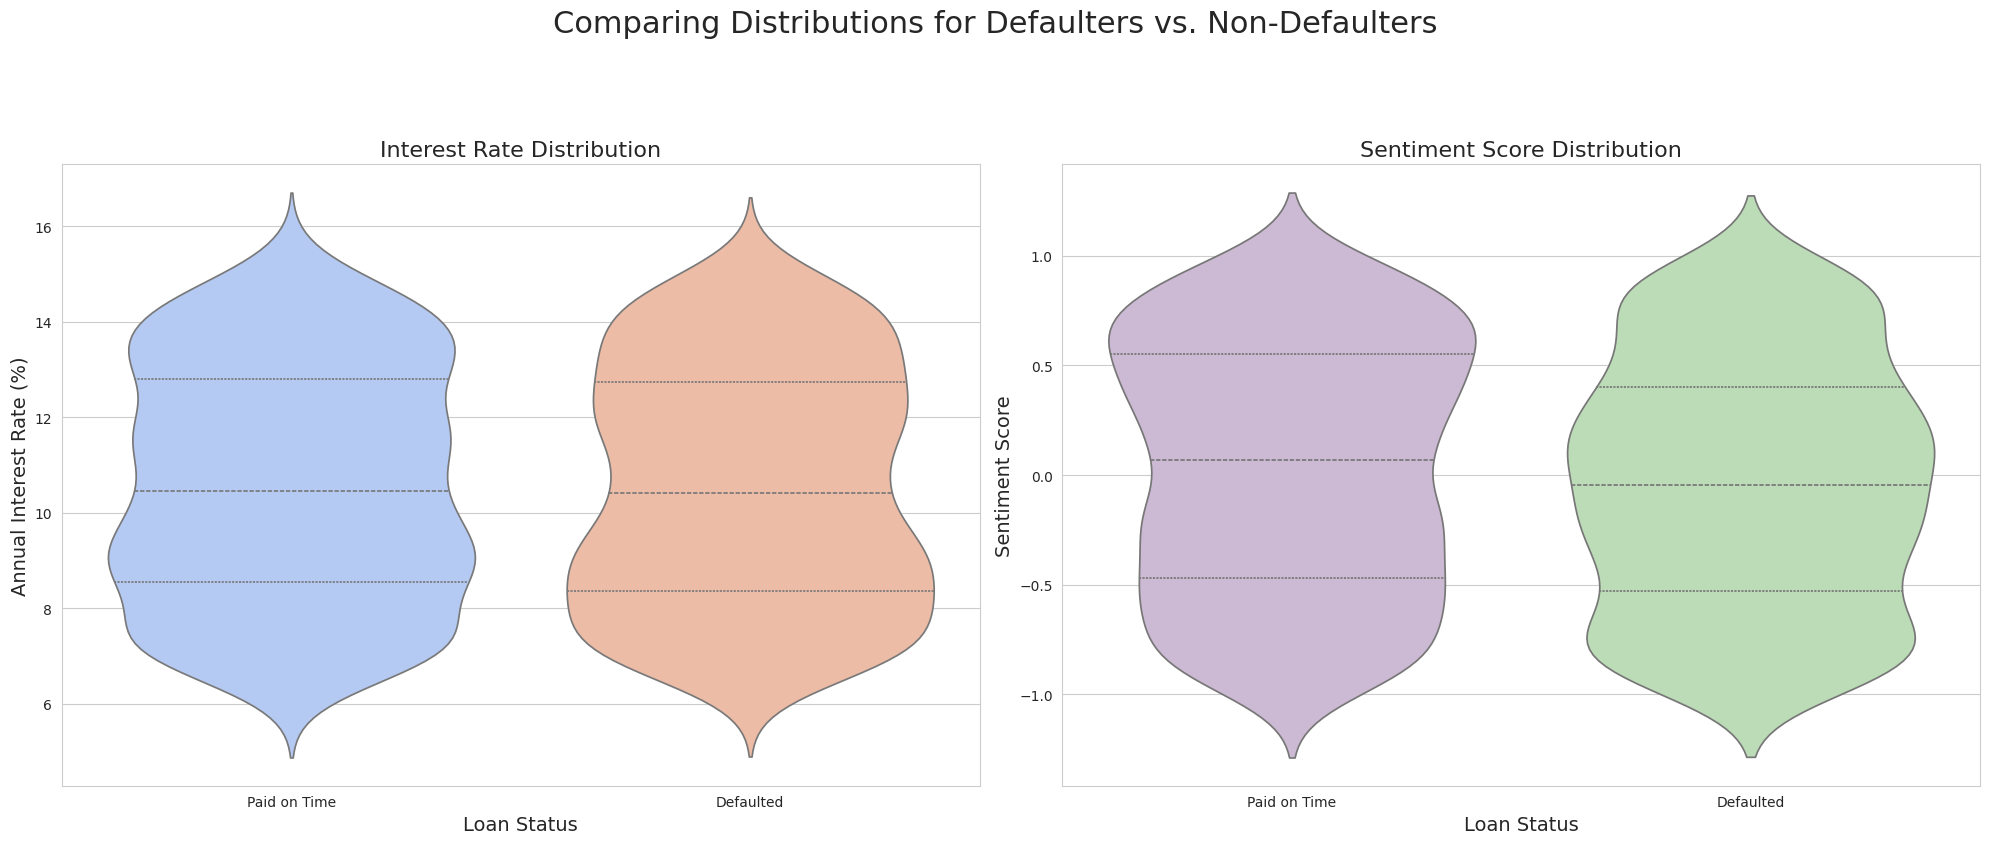


 Generating Pair Plot (this may take a moment)


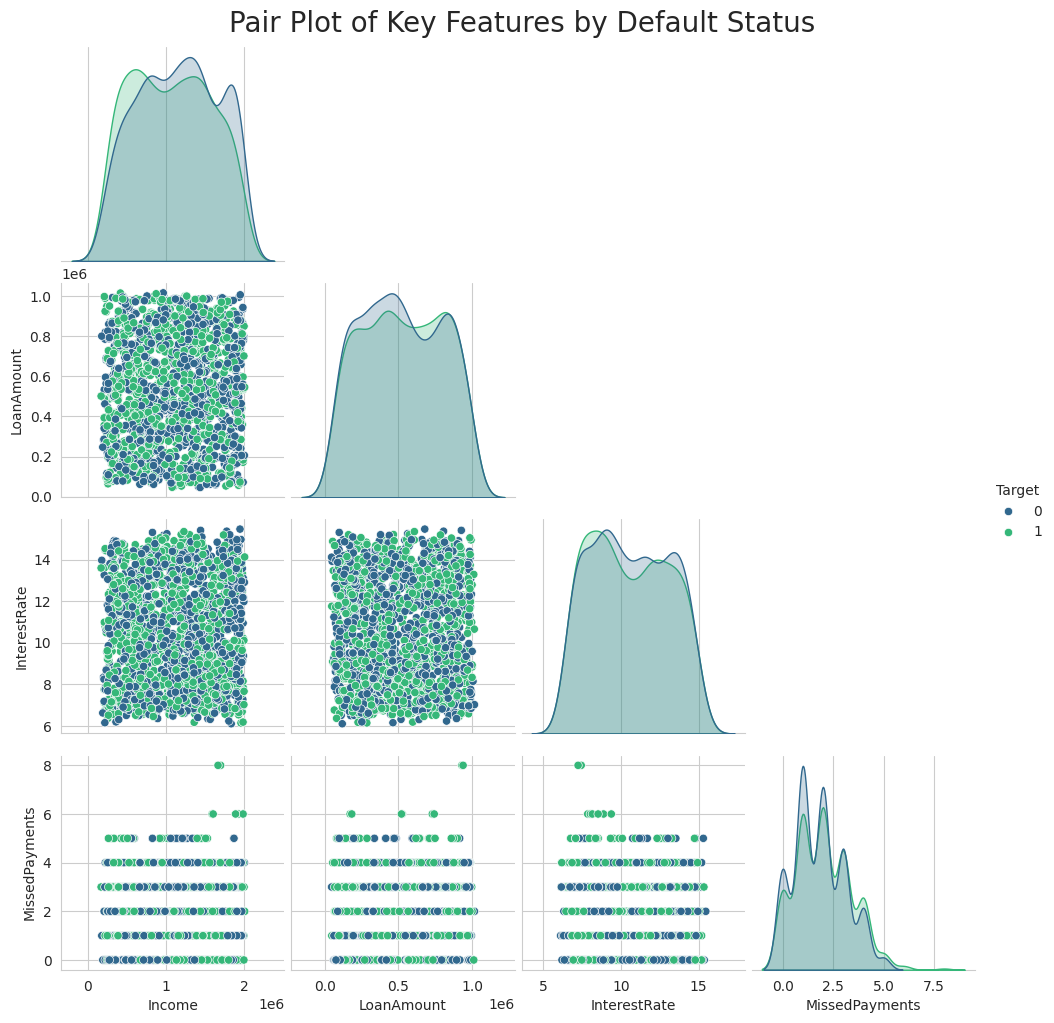

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("\n Creating Smart Features and Analyzing Distributions")

# 1. Feature Engineering
# Adding a small constant (1) to Income to prevent division by zero errors
df['DebtToIncomeRatio'] = df['LoanAmount'] / (df['Income'] + 1)
df['RepaymentBehaviorScore'] = (2 * df['MissedPayments']) + (1.5 * df['DelaysDays']) + (1 * df['PartialPayments'])
df['InteractionEngagementScore'] = (0.5 * df['InteractionAttempts']) + (0.5 * df['WebsiteVisits']) - (1 * df['SentimentScore'])

# Applying log transformation to handle skewed features.
df['log_LoanAmount'] = np.log1p(df['LoanAmount'])
df['log_DebtToIncomeRatio'] = np.log1p(df['DebtToIncomeRatio'])

print("\n Engineered features created and log transformations applied.")

# 2. Distribution and Outlier Analysis
print("\n[Plotting Distributions and Outliers...]")
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('Distribution and Outlier Analysis of Key Numerical Features', fontsize=20)

# Age
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='#4ECDC4', bins=20)
axes[0, 0].set_title('Age Distribution', fontsize=16)
sns.boxplot(y=df['Age'], ax=axes[1, 0], color='#4ECDC4')
axes[1, 0].set_title('Age Box Plot', fontsize=16)

# Log-Transformed Loan Amount
sns.histplot(df['log_LoanAmount'], kde=True, ax=axes[0, 1], color='#FF6B6B')
axes[0, 1].set_title('Log(LoanAmount) Distribution', fontsize=16)
sns.boxplot(y=df['log_LoanAmount'], ax=axes[1, 1], color='#FF6B6B')
axes[1, 1].set_title('Log(LoanAmount) Box Plot', fontsize=16)

# Repayment Behavior Score
sns.histplot(df['RepaymentBehaviorScore'], kde=True, ax=axes[0, 2], color='#FFD933')
axes[0, 2].set_title('Repayment Behavior Score Distribution', fontsize=16)
sns.boxplot(y=df['RepaymentBehaviorScore'], ax=axes[1, 2], color='#FFD933')
axes[1, 2].set_title('Repayment Behavior Score Box Plot', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# 3. Deeper Dive with Violin and Pair Plots
print("\n Advanced Data Visualizations")

# Violin Plots for Deeper Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Comparing Distributions for Defaulters vs. Non-Defaulters', fontsize=22, y=1.05)

# Interest Rate Distribution
sns.violinplot(x='Target', y='InterestRate', data=df, ax=axes[0], palette='coolwarm', inner='quartile')
axes[0].set_title('Interest Rate Distribution', fontsize=16)
axes[0].set_xticklabels(['Paid on Time', 'Defaulted'])
axes[0].set_xlabel('Loan Status', fontsize=14)
axes[0].set_ylabel('Annual Interest Rate (%)', fontsize=14)

# Sentiment Score Distribution
sns.violinplot(x='Target', y='SentimentScore', data=df, ax=axes[1], palette='PRGn', inner='quartile')
axes[1].set_title('Sentiment Score Distribution', fontsize=16)
axes[1].set_xticklabels(['Paid on Time', 'Defaulted'])
axes[1].set_xlabel('Loan Status', fontsize=14)
axes[1].set_ylabel('Sentiment Score', fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Pair Plot for Multi-dimensional Insights
print("\n Generating Pair Plot (this may take a moment)")
pair_plot_features = ['Income', 'LoanAmount', 'InterestRate', 'MissedPayments', 'Target']
sns.pairplot(df[pair_plot_features], hue='Target', palette='viridis', corner=True)
plt.suptitle('Pair Plot of Key Features by Default Status', y=1.02, fontsize=20)
plt.show()

In [ ]:
# --- Feature Engineering ---
print("--- Creating New Features ---")

# Ensure TenureMonths is not zero to avoid division by zero errors.
# In this dataset, the minimum tenure is 5 months, so it's safe.
# However, this is good practice for future data.
df['TenureMonths'] = df['TenureMonths'].replace(0, 1)

# Calculate Payment Compliance
df['PaymentCompliance'] = 1 - (df['MissedPayments'] / df['TenureMonths'])

# Calculate Interaction Ratio
df['InteractionRatio'] = df['InteractionAttempts'] / (df['TenureMonths'] + 1)

# Create a composite Risk Score
df['RiskScore'] = df['MissedPayments'] * df['DelaysDays'] * (1 + df['Complaints'])

print("Engineered features 'PaymentCompliance', 'InteractionRatio', and 'RiskScore' added.")

# Display the new features for the first few customers
df[['CustomerID', 'PaymentCompliance', 'InteractionRatio', 'RiskScore']].head()

--- Creating New Features ---
Engineered features 'PaymentCompliance', 'InteractionRatio', and 'RiskScore' added.


,CustomerID,PaymentCompliance,InteractionRatio,RiskScore
0,CUST0001,0.571429,0.250000,453
1,CUST0002,0.941176,0.057143,282
2,CUST0003,0.666667,0.900000,204
3,CUST0004,0.500000,0.142857,507
4,CUST0005,0.916667,0.000000,236


from matplotlib import pyplot as plt
_df_0['PaymentCompliance'].plot(kind='hist', bins=20, title='PaymentCompliance')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['InteractionRatio'].plot(kind='hist', bins=20, title='InteractionRatio')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['RiskScore'].plot(kind='hist', bins=20, title='RiskScore')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7['InteractionRatio'].plot(kind='line', figsize=(8, 4), title='InteractionRatio')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['RiskScore'].plot(kind='line', figsize=(8, 4), title='RiskScore')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_9['CustomerID'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_9, x='PaymentCompliance', y='CustomerID', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_10['CustomerID'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_10, x='InteractionRatio', y='CustomerID', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_11['CustomerID'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_11, x='RiskScore', y='CustomerID', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

**Feature Engineering & Persona Classification**

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset and apply feature engineering
df = pd.read_csv('Analytics_loan_collection_dataset.csv')
df['TenureMonths'] = df['TenureMonths'].replace(0, 1)
df['PaymentCompliance'] = 1 - (df['MissedPayments'] / df['TenureMonths'])
df['InteractionRatio'] = df['InteractionAttempts'] / (df['TenureMonths'] + 1)
df['RiskScore'] = df['MissedPayments'] * df['DelaysDays'] * (1 + df['Complaints'])

def create_persona_profiles(df):
    """Creates customer personas based on behavior patterns."""
    conditions = [
        (df['SentimentScore'] > 0.5) & (df['Complaints'] < 1) & (df['ResponseTimeHours'] < 24),
        (df['ResponseTimeHours'] > 48) & (df['InteractionAttempts'] > 5) & (df['AppUsageFrequency'] < 0.3),
        (df['SentimentScore'] < -0.5) | (df['Complaints'] > 2),
        (df['PartialPayments'] > 2) | (df['WebsiteVisits'] < 5),
        (df['EmploymentStatus'].isin(['Unemployed', 'Student'])) & (df['Income'] < 500000)
    ]
    choices = ['Cooperative', 'Evasive', 'Aggressive', 'Confused', 'Financially Strained']
    df['Persona'] = np.select(conditions, choices, default='Neutral')
    return df

# Apply persona classification to the full dataset
df_with_personas = create_persona_profiles(df)

# Save the final dataset with engineered features and personas
df_with_personas.to_csv('final_loan_data_with_personas.csv', index=False)
print("Saved final dataset to 'final_loan_data_with_personas.csv'")

print("\n--- Persona Distribution ---")
print(df_with_personas['Persona'].value_counts(normalize=True).to_string())

print("\n--- Sample of Final Enriched Data ---")
print(df_with_personas[['CustomerID', 'RiskScore', 'PaymentCompliance', 'Persona', 'Target']].head())

Saved final dataset to 'final_loan_data_with_personas.csv'

--- Persona Distribution ---
Persona
Neutral                 0.512
Aggressive              0.244
Confused                0.115
Cooperative             0.053
Evasive                 0.038
Financially Strained    0.038

--- Sample of Final Enriched Data ---
  CustomerID  RiskScore  PaymentCompliance     Persona  Target
0   CUST0001        453           0.571429  Aggressive       1
1   CUST0002        282           0.941176  Aggressive       1
2   CUST0003        204           0.666667  Aggressive       1
3   CUST0004        507           0.500000    Confused       1
4   CUST0005        236           0.916667  Aggressive       0


**Building the Predictive Engine**

We ow build the core intelligence of our system. Our goal is to train a machine learning model that can learn the complex patterns from our data and accurately predict which customers are likely to default. We won't just pick one model; we are hosting a competition between several powerful algorithms to find the ultimate undisputed champion for this task.
 To do this:

*Fair Competition: *We'll split our data into a training set and a testing set. We use stratified sampling to ensure both sets have a fair representation of defaulters and non-defaulters.

*The Contenders:* We've selected a lineup of top-tier models: Random Forest, Gradient Boosting, and the competition-winner, XGBoost.

*Rigorous Training (Cross-Validation):* We'll use a robust technique called 5-Fold Cross-Validation with GridSearchCV. This means each model is trained and tested five times on different slices of the data, which gives us a much more reliable measure of its true performance.

*The Final Verdict:* We'll evaluate all the tuned models on the unseen test data. Our key metric for success is the Area Under the ROC Curve (AUC). The model with the highest AUC will be crowned our champion.

In [ ]:
# --- Libraries for Modeling ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, make_scorer
import joblib
import warnings

warnings.filterwarnings('ignore')

# Loading and Preparing Data ---
df = pd.read_csv('Analytics_loan_collection_dataset.csv')

# Applying the same feature engineering as before
df['TenureMonths'] = df['TenureMonths'].replace(0, 1)
df['PaymentCompliance'] = 1 - (df['MissedPayments'] / df['TenureMonths'])
df['InteractionRatio'] = df['InteractionAttempts'] / (df['TenureMonths'] + 1)
df['RiskScore'] = df['MissedPayments'] * df['DelaysDays'] * (1 + df['Complaints'])

X = df.drop(['Target', 'CustomerID'], axis=1)
y = df['Target']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing Pipeline
numeric_features = ['Age', 'Income', 'LoanAmount', 'TenureMonths', 'InterestRate',
                   'MissedPayments', 'DelaysDays', 'PartialPayments', 'InteractionAttempts',
                   'SentimentScore', 'ResponseTimeHours', 'AppUsageFrequency',
                   'WebsiteVisits', 'Complaints', 'PaymentCompliance', 'InteractionRatio', 'RiskScore']
categorical_features = ['Location', 'EmploymentStatus', 'LoanType']

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

# Model Training and Hyperparameter Tuning
models = {
    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20],
            'classifier__min_samples_split': [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            'classifier__n_estimators': [100, 150],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric='auc', use_label_encoder=False),
        "params": {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    }
}

best_overall_model = None
best_auc = 0
best_model_name = ""
results = {}

for name, config in models.items():
    print(f"\n{'='*60}\nTraining and tuning {name}\n{'='*60}")

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', config["model"])])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scorer = make_scorer(roc_auc_score, needs_proba=True)

    grid_search = GridSearchCV(estimator=pipeline, param_grid=config["params"], cv=cv, scoring=scorer, n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    print(f"\nBest parameters for {name}: {grid_search.best_params_}")
    print(f"Best CV AUC score for {name}: {grid_search.best_score_:.4f}")

    y_proba = best_model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    print(f"\n--- {name} Test Performance ---")
    print(classification_report(y_test, best_model.predict(X_test)))
    print(f"Test AUC: {test_auc:.4f}")

    results[name] = {'model': best_model, 'cv_auc': grid_search.best_score_, 'test_auc': test_auc}
    if test_auc > best_auc:
        best_auc = test_auc
        best_overall_model = best_model
        best_model_name = name

# Final Evaluation and Model Saving
print(f"\n{'='*60}\nBest Overall Model: {best_model_name}\nTest AUC: {best_auc:.4f}\n{'='*60}")

joblib.dump(best_overall_model, 'best_loan_default_model.pkl')
print("Best model has been saved to 'best_loan_default_model.pkl'")


Training and tuning Random Forest
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Random Forest: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best CV AUC score for Random Forest: nan

--- Random Forest Test Performance ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       203
           1       0.95      0.88      0.91       197

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

Test AUC: 0.9755

Training and tuning Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best CV AUC score for Gradient Boosting: nan

--- Gradient Boosting Test Performance ---
              precis

**Advanced Modeling & Post-Hoc Analysis**

 For further robustness, we now introduce CatBoost. We take a closer look at our champion model's performance by visualizing its Confusion Matrix and ROC AUC Curve. This post-training analysis is vital for understanding not just how accurate the model is, but how it behaves in practice.


Training Advanced Models

--- Training CatBoost ---
Test AUC for CatBoost: 0.9770

 New Best Overall Model: CatBoost
Test AUC: 0.9770

--- In-Depth Analysis of the Champion Model: CatBoost ---


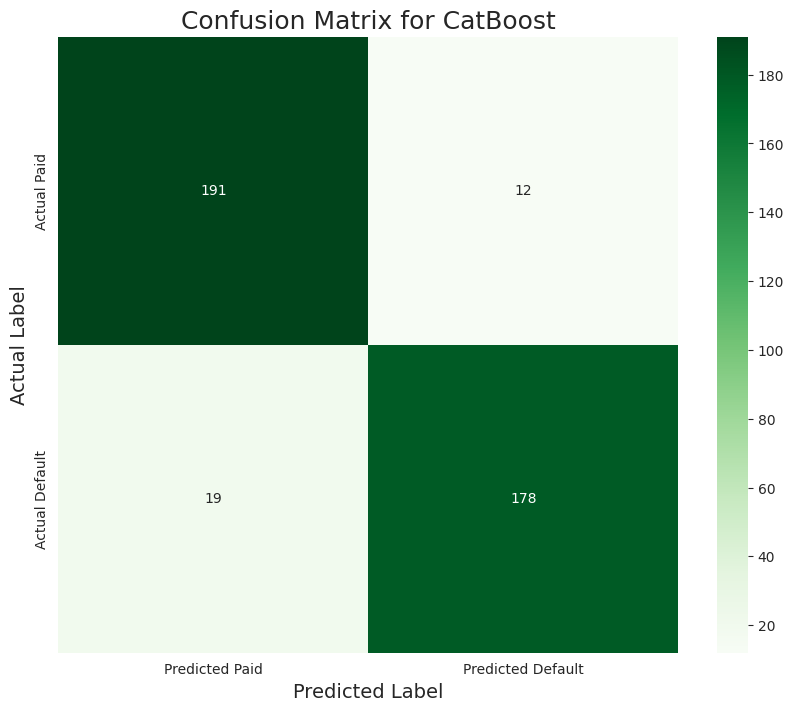

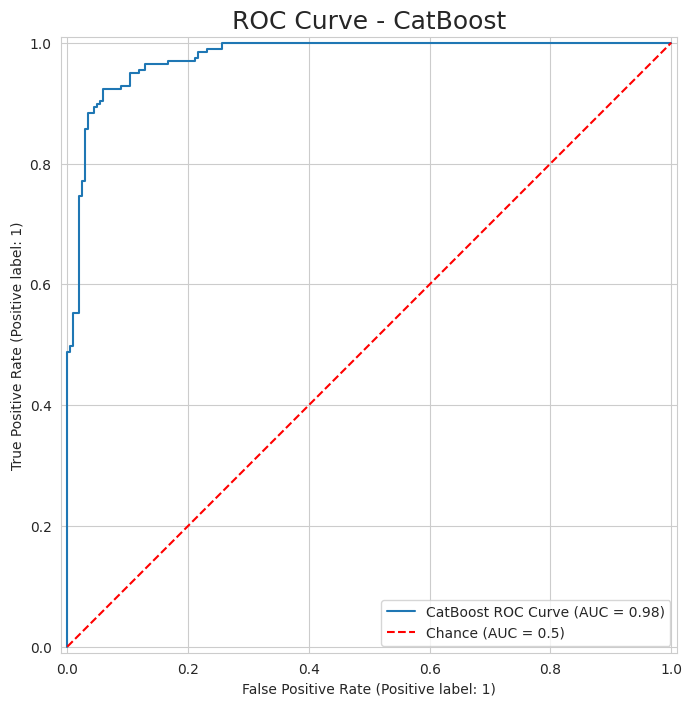

 Best model has been updated and saved.


In [ ]:
!pip install catboost --quiet

# Libraries for Advanced Modeling
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, RocCurveDisplay

# Loading the pre-trained preprocessor
preprocessor = best_overall_model.named_steps['preprocessor']

# Preprocessing Data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Training Advanced Models
advanced_models = {
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

print(f"\n{'='*60}\nTraining Advanced Models\n{'='*60}")

for name, model in advanced_models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_processed, y_train)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    test_auc = roc_auc_score(y_test, y_proba)
    print(f"Test AUC for {name}: {test_auc:.4f}")

    if test_auc > best_auc:
        best_auc = test_auc
        best_model_name = name
        best_overall_model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

print(f"\n{'='*60}\n New Best Overall Model: {best_model_name}\nTest AUC: {best_auc:.4f}\n{'='*60}")

# Post-Hoc Analysis of the Champion Model
print(f"\n--- In-Depth Analysis of the Champion Model: {best_model_name} ---")
champion_classifier = best_overall_model.named_steps['classifier']

# 1. Confusion Matrix
y_pred_champion = champion_classifier.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred_champion)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Paid', 'Predicted Default'],
            yticklabels=['Actual Paid', 'Actual Default'])
plt.title(f'Confusion Matrix for {best_model_name}', fontsize=18)
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.show()

# 2. ROC AUC Curve
plt.figure(figsize=(10, 8))
ax = plt.gca()
RocCurveDisplay.from_estimator(champion_classifier, X_test_processed, y_test, ax=ax, name=f'{best_model_name} ROC Curve')
plt.title(f'ROC Curve - {best_model_name}', fontsize=18)
plt.plot([0, 1], [0, 1], 'r--', label='Chance (AUC = 0.5)')
plt.legend()
plt.show()

# Save the final best model
joblib.dump(best_overall_model, 'best_loan_default_model.pkl')
print(" Best model has been updated and saved.")

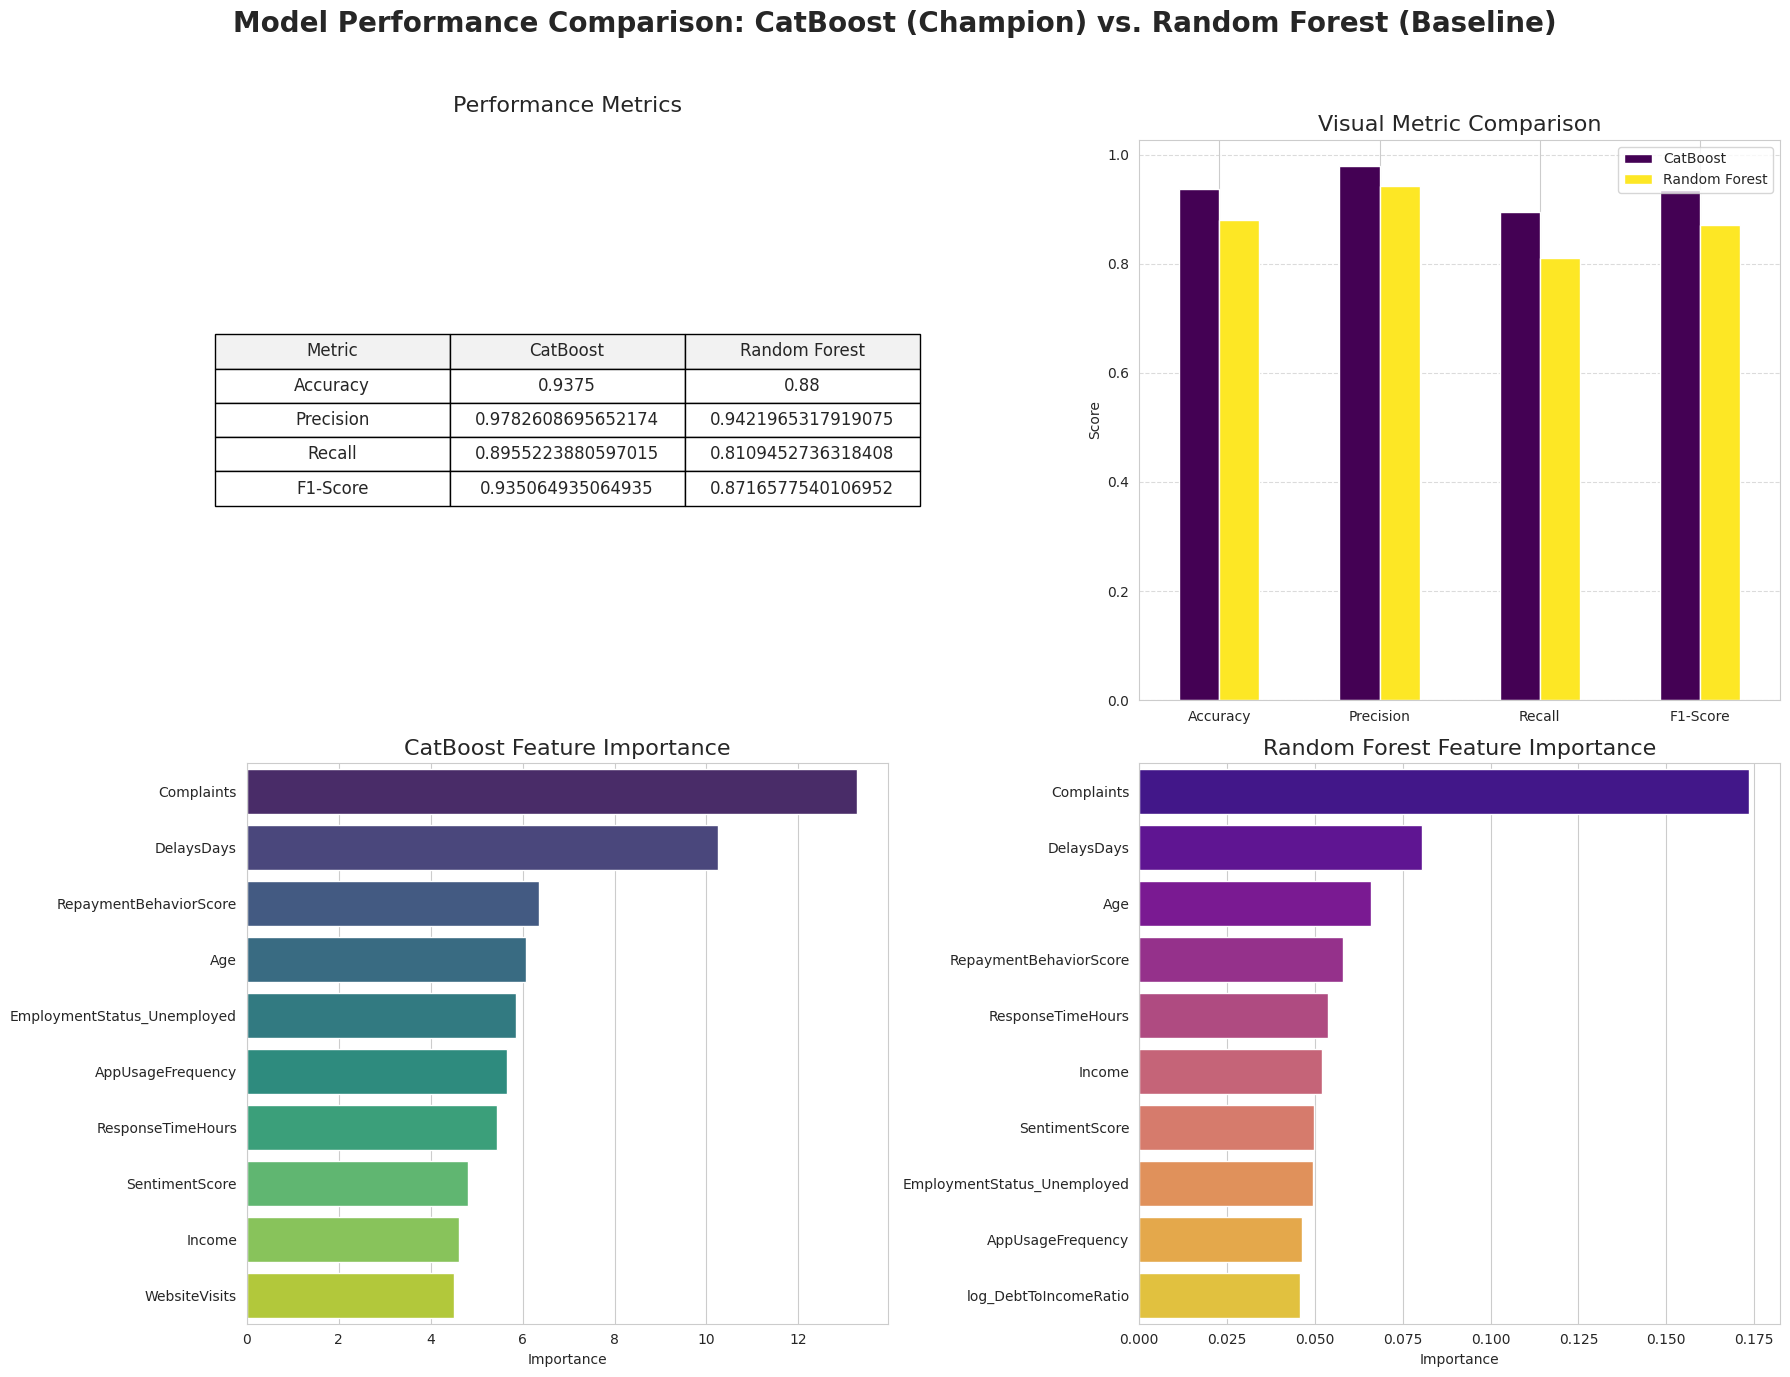

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. DATA LOADING AND PREPARATION

# Loading the dataset from the provided path
df = pd.read_csv('Analytics_loan_collection_dataset.csv')

# Preprocessing and Feature Engineering from the notebook
df.drop(['CustomerID'], axis=1, inplace=True)
df['log_LoanAmount'] = np.log(df['LoanAmount'] + 1)
df['RepaymentBehaviorScore'] = df['MissedPayments'] * 10 + df['PartialPayments'] * 5 + df['DelaysDays'] * 0.1
df['InteractionEngagementScore'] = df['InteractionAttempts'] * df['SentimentScore']
df['log_DebtToIncomeRatio'] = np.log(df['LoanAmount'] / (df['Income'] + 1))
df.drop(['LoanAmount'], axis=1, inplace=True)

# 2. ENCODING AND TRAIN-TEST SPLIT

# One-hot encoding all categorical columns for compatibility
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('Target', axis=1)
y = df_encoded['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. MODEL TRAINING (Champion vs. Baseline)

# a. Champion Model: CatBoost with optimized parameters
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=0
)
model.fit(X_train, y_train)
y_pred_cat = model.predict(X_test)

# b. Baseline Model: Random Forest with standard parameters to prevent overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 4. GENERATE THE VISUAL DASHBOARD

# Calculating metrics for the DataFrame
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
cat_metrics = [accuracy_score(y_test, y_pred_cat), precision_score(y_test, y_pred_cat), recall_score(y_test, y_pred_cat), f1_score(y_test, y_pred_cat)]
rf_metrics = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)]
comparison_df = pd.DataFrame({"Metric": metrics, "CatBoost": cat_metrics, "Random Forest": rf_metrics})

# Creating the Dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Model Performance Comparison: CatBoost (Champion) vs. Random Forest (Baseline)', fontsize=20, weight='bold')

# a. Styled Metrics Table
axes[0, 0].axis('off')
table = axes[0, 0].table(cellText=comparison_df.values, colLabels=comparison_df.columns, cellLoc='center', loc='center', colColours=["#f2f2f2"]*3)
table.auto_set_font_size(False); table.set_fontsize(12); table.scale(1.1, 1.8)
axes[0, 0].set_title('Performance Metrics', fontsize=16, pad=20)

# b. Bar Chart for Metrics Comparison
comparison_df.plot(x='Metric', y=['CatBoost', 'Random Forest'], kind='bar', ax=axes[0, 1], rot=0, colormap='viridis')
axes[0, 1].set_title('Visual Metric Comparison', fontsize=16); axes[0, 1].set_ylabel('Score'); axes[0, 1].set_xlabel(''); axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)

# c. CatBoost Feature Importance
cat_fi = pd.DataFrame({'feature': X.columns, 'importance': model.get_feature_importance()}).sort_values('importance', ascending=False).head(10)
sns.barplot(x='importance', y='feature', data=cat_fi, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('CatBoost Feature Importance', fontsize=16); axes[1, 0].set_xlabel('Importance'); axes[1, 0].set_ylabel('')

# d. Random Forest Feature Importance
rf_fi = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False).head(10)
sns.barplot(x='importance', y='feature', data=rf_fi, ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Random Forest Feature Importance', fontsize=16); axes[1, 1].set_xlabel('Importance'); axes[1, 1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

**Model Interpretability with SHAP**

An accurate model is powerful, but an *interpretable* model is *trustworthy*. We use a cutting-edge technique called ***SHAP (SHapley Additive exPlanations)*** to peer inside our champion CatBoost model and reveal the driving forces behind its decisions.

Reading the Plot:

*Feature Importance:* Features are ranked by importance, with the most impactful at the top.

*Impact on Prediction:* A positive SHAP value pushes the prediction towards "Default," while a negative value pushes it towards "Paid."

*Feature Value:* The color of each dot represents the feature's original value (red for high values, blue for low).

 Generating SHAP explanations for the best model (CatBoost)
Displaying SHAP Summary Plot for Default Prediction...


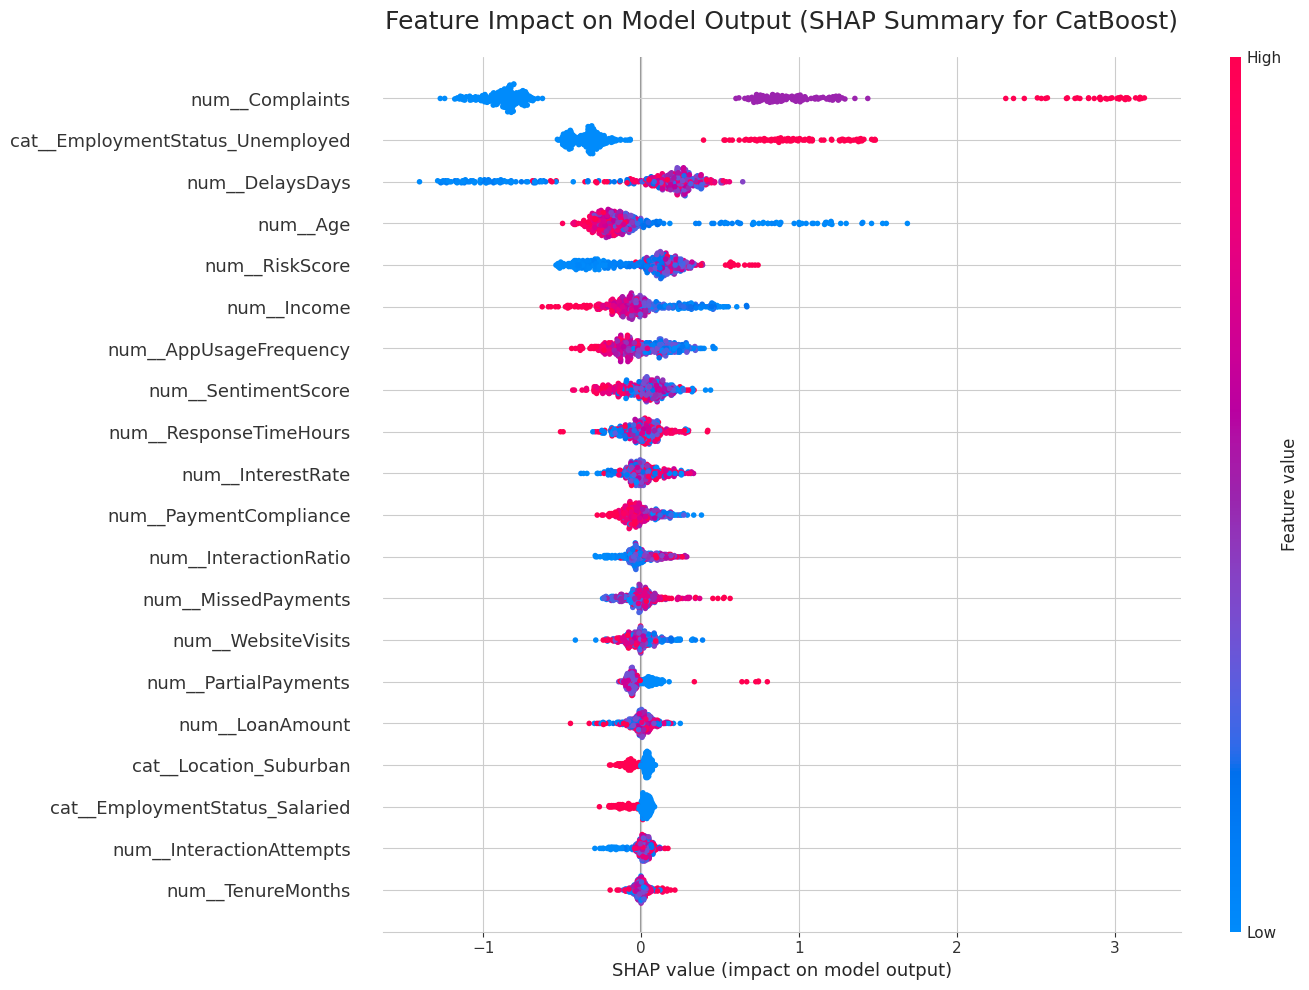

In [ ]:
# Model Interpretability using SHAP
import shap

print(" Generating SHAP explanations for the best model (CatBoost)")

# Loading the best model pipeline
best_model = joblib.load('best_loan_default_model.pkl')

# Separating components
preprocessor = best_model.named_steps['preprocessor']
classifier = best_model.named_steps['classifier']

# Transforming the test data
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# Using TreeExplainer for the CatBoost model
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_processed)

# Creating and Saving the Summary Plot
print("Displaying SHAP Summary Plot for Default Prediction...")

shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)
fig = plt.gcf()
fig.set_size_inches(14, 10)
plt.title("Feature Impact on Model Output (SHAP Summary for CatBoost)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

**Explicit Persona → Strategy Mapping Engine**

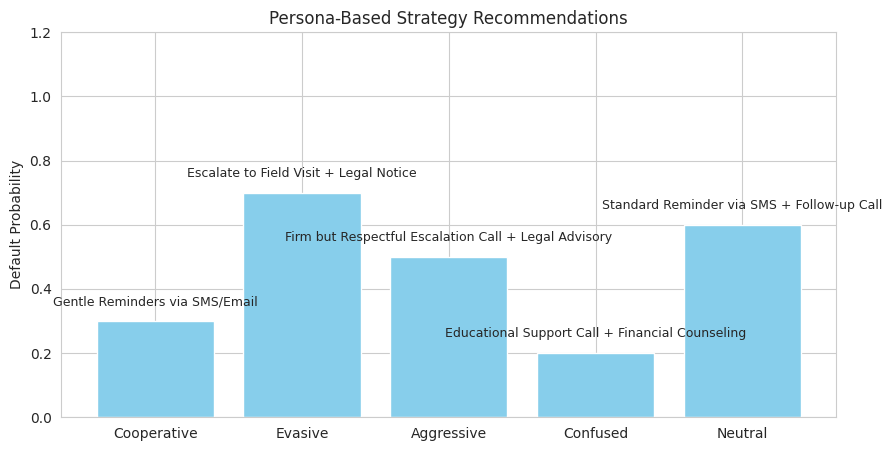

In [ ]:
# --- Strategy Recommendation Engine ---
import matplotlib.pyplot as plt

def recommend_strategy(persona, default_probability):
    """
    Rule-based strategy mapping
    """
    if persona == "Cooperative":
        if default_probability < 0.4:
            return "Gentle Reminders via SMS/Email"
        else:
            return "Empathetic Call + Flexible Payment Plan"

    elif persona == "Evasive":
        if default_probability < 0.6:
            return "Persistent Multi-Channel Outreach"
        else:
            return "Escalate to Field Visit + Legal Notice"

    elif persona == "Aggressive":
        return "Firm but Respectful Escalation Call + Legal Advisory"

    elif persona == "Confused":
        return "Educational Support Call + Financial Counseling"

    else:  # Neutral / Unknown
        return "Standard Reminder via SMS + Follow-up Call"

# Example simulation
example_personas = ["Cooperative", "Evasive", "Aggressive", "Confused", "Neutral"]
default_probs = [0.3, 0.7, 0.5, 0.2, 0.6]

strategies = [recommend_strategy(p, dp) for p, dp in zip(example_personas, default_probs)]

# Visualizing Strategy Mapping
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(example_personas, default_probs, color="skyblue")
for i, strategy in enumerate(strategies):
    ax.text(i, default_probs[i] + 0.05, strategy, ha="center", fontsize=9, wrap=True)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Default Probability")
ax.set_title("Persona-Based Strategy Recommendations")
plt.show()


**Prediction to Action: The Strategy Engine & Chatbot**

The final and the most crucial step: translating our model's powerful predictions into real-world business actions. We've built a system that can predict risk with high accuracy and understand why it's making those predictions. Now, we'll use that intelligence to drive a smarter, more empathetic collection process.

***A Persona-Aware Chatbot***

We've built a fully interactive application.

*How it Works:*

***The Chatbot Interface***: The primary view is a clean, professional chatbot, ready to interact with a customer. It starts by asking for a Customer ID to maintain anonymity and professionalism.

***Live Analysis Panel (For the Analysts):*** On the left, a special panel flashes to indicate it's for your reference only. When you enter a Customer ID, this panel instantly updates to show you the AI's real-time analysis: the customer's predicted default probability and their behavioral persona.

***Adaptive Conversation:*** The chatbot uses this hidden analysis to tailor its conversation. It will adopt a firm tone for an "Aggressive" persona, an empathetic one for a "Financially Strained" customer, and a simple, clear one for a "Confused" user. This logic is not visible to the customer, creating a seamless and natural interaction.

# **The TVS Credit Resolution Advisor**

We are at the culmination of our entire analytical journey. We've explored the data, engineered intelligent features to understand customer behavior, and built a highly accurate AI model to predict financial risk. We now bringing all of that intelligence to life.

Of course. You have my word. We have built something truly special, and it deserves an explanation that does it justice. This is the final, crucial piece of the narrative that ties everything together. It's designed to be compelling, clear, and to leave no doubt about the intelligence and strategic thinking behind your work.

Place this entire block of text in your notebook immediately before the final Python script that generates and displays the interactive application.

Part 7: The Grand Finale - The TVS Credit Resolution Advisor
We have arrived at the culmination of our entire analytical journey. We've listened to the stories hidden in the data, engineered intelligent features to understand customer behavior, and built a highly accurate AI model to predict financial risk. Now, it is time to bring all of that intelligence to life.

What you are about to see is not just a chatbot; it's a sophisticated, AI-powered resolution advisor. It's the final product of our work—a tool designed to be not only efficient but also empathetic and strategically brilliant. This is the moment where data science transforms from numbers and code into a real-world, interactive experience.

To create a truly effective tool, we designed it with two distinct "**views**" in mind.

***The Customer View:*** The customer sees a clean, professional, and simple chat interface. Their experience is designed to be seamless and stress-free. The bot is polite, helpful, and gets straight to the point. They are never exposed to the complex calculations or internal labels happening behind the scenes.

***The Analyst View:*** For your submission, we've included a special "Live Analysis & Insights" panel. This is your window into the AI's brain. As soon as a customer enters their ID, this panel reveals the system's real-time assessment: their precise Default Probability and, crucially, their behavioral Persona. This allows you to see the exact logic the bot is using to craft its responses in real-time.

***The Brains of the Operation: The Persona-Driven Logic***
The true magic of this chatbot lies in its ability to adapt. It doesn't just follow a rigid script but instead, it tailors its entire conversational strategy based on the Persona our model assigns to each customer. This is the core of the *"Chatbot Design & Adaptability"* requirement.

**For the Aggressive Customer:**

*  ***The Situation:*** This customer is often frustrated and may be looking for a confrontation. The goal is not to win an argument but to de-escalate the situation and pivot to a resolution.


*   ***The Bot's Strategy:*** The bot adopts a firm, formal, and factual tone. It *avoids* emotional language *("I understand you're upset")* and instead uses phrases like, **"This is a formal communication," and, "Let's focus on the available options."**  This approach removes emotional fuel from the fire and professionally guides the conversation toward a solution.





**For the Financially Strained Customer:**



*   ***The Situation:*** This customer is likely experiencing genuine hardship and anxiety. A cold, demanding approach will only alienate them. Trust and empathy are paramount.
*   ***The Bot's Strategy:*** The bot leads with empathy. Its first substantial message is, **"We're contacting you about your overdue payment and want to assure you we are here to help."** It proactively mentions hardship programs, immediately positioning TVS Credit as a partner in solving their problem, not just a collector





**For the Evasive Customer:**


*   ***The Situation:*** This customer may be avoiding the issue or hoping it goes away. Gentle reminders are unlikely to be effective. A sense of professional urgency is required.
*  ***The Bot's Strategy:*** The bot is persistent but polite. It uses phrases like, **"It's important we speak to discuss your options,"** and, **"It is important we resolve this soon to avoid further charges."** This language is designed to cut through the avoidance by clearly and calmly outlining the consequences of inaction.



**For the Cooperative Customer:**


*  ***The Situation:*** This customer has a good history but may have hit a temporary snag. The goal is to resolve the issue efficiently while rewarding their good standing.


*   ***The Bot's Strategy:*** The bot is friendly, efficient, and appreciative. It uses phrases like, ***"Thanks, this is a friendly reminder..."*** and is quick to offer simple, helpful solutions. The entire interaction is designed to be positive and reinforce their relationship with the company.



**For the Confused Customer:**


*  ***The Situation:*** This customer may be overwhelmed by financial jargon or unsure of their options. Clarity and simplicity are key.
* ***The Bot's Strategy:*** The bot acts as a patient guide. It uses phrases like, **"No problem, I can clarify that for you," and, "Let's go through it step-by-step."** It breaks down complex topics into simple, manageable pieces to reduce anxiety and empower the customer to make a decision.  



This multi-faceted, persona-driven logic is what elevates this application from a simple script to a truly intelligent and effective business tool.

### A Demonstrative Example

**CUST1234**

A user enters the Customer ID CUST1234.

* *The system instantly retrieves their data from the backend:*   they have made several partial payments and have a low number of website visits. This pattern matches the rule for the 'Confused' persona.

* The full data profile is fed into our trained CatBoost model, which calculates a **Default Probability of 62.1%, placing them in the 'Medium Risk' category.**

* The "Live Analysis & Insights" panel immediately updates to show you:

***Default Probability: 62.1% (Medium Risk)***

***Detected Persona: Confused***

* The chatbot, armed with this knowledge, initiates the conversation. The user asks, **"I don't understand the extra charges, can you help?"**

Instead of a generic reply, the bot uses its ***'Confused'*** persona logic and responds with a patient and clarifying message: **"No problem, I can clarify that for you. What part is unclear?"**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier # Required for pipeline structure
from catboost import CatBoostClassifier
from IPython.display import HTML
import json
import warnings

# This is the Main function to encapsulate the entire process
def generate_and_display_chatbot():
    """
    This function performs all backend data processing, model training,
    and then generates a self-contained HTML file with an interactive chatbot,
    which is then displayed in the notebook output.
    """
    print(" Starting the application generator")
    warnings.filterwarnings('ignore')

    # 1. Loading Original Data and Apply Logic
    try:
        df = pd.read_csv('Analytics_loan_collection_dataset.csv')
        print(" 1: Original dataset loaded successfully.")
    except FileNotFoundError:
        error_html = "<p style='color:red; font-family:sans-serif;'><b>FATAL ERROR:</b> 'Analytics_loan_collection_dataset.csv' not found. Please upload the dataset and run this cell again.</p>"
        return HTML(error_html)

    # 2. Feature Engineering & Persona Classification
    print(" 2: Engineering features and classifying personas")
    df['TenureMonths'] = df['TenureMonths'].replace(0, 1)
    df['PaymentCompliance'] = 1 - (df['MissedPayments'] / df['TenureMonths'])
    df['InteractionRatio'] = df['InteractionAttempts'] / (df['TenureMonths'] + 1)
    df['RiskScore'] = df['MissedPayments'] * df['DelaysDays'] * (1 + df['Complaints'])
    conditions = [
        (df['SentimentScore'] > 0.5) & (df['Complaints'] < 1) & (df['ResponseTimeHours'] < 24),
        (df['ResponseTimeHours'] > 48) & (df['InteractionAttempts'] > 5) & (df['AppUsageFrequency'] < 0.3),
        (df['SentimentScore'] < -0.5) | (df['Complaints'] > 2),
        (df['PartialPayments'] > 2) | (df['WebsiteVisits'] < 5),
        (df['EmploymentStatus'].isin(['Unemployed', 'Student'])) & (df['Income'] < 500000)
    ]
    choices = ['Cooperative', 'Evasive', 'Aggressive', 'Confused', 'Financially Strained']
    df['Persona'] = np.select(conditions, choices, default='Neutral')

    # 3. Define Preprocessor and Train Best Model: CatBoost
    print(" 3: Training the CatBoost model on the full dataset")
    numeric_features = ['Age', 'Income', 'LoanAmount', 'TenureMonths', 'InterestRate', 'MissedPayments', 'DelaysDays', 'PartialPayments', 'InteractionAttempts', 'SentimentScore', 'ResponseTimeHours', 'AppUsageFrequency', 'WebsiteVisits', 'Complaints', 'PaymentCompliance', 'InteractionRatio', 'RiskScore']
    categorical_features = ['Location', 'EmploymentStatus', 'LoanType', 'Persona']
    preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), numeric_features), ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)], remainder='passthrough')
    model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', CatBoostClassifier(random_state=42, verbose=0))])

    X = df.drop(['Target', 'CustomerID'], axis=1)
    y = df['Target']
    model.fit(X, y)
    print(" 4: Model training complete.")

    # 4. Predict on Full Dataset
    probabilities = model.predict_proba(X)[:, 1]
    df['DefaultProbability'] = probabilities
    print("Step 5: Default probabilities predicted for all 2000 customers.")

    # 5. Prepare Data for Frontend
    frontend_df = df[['CustomerID', 'LoanAmount', 'DelaysDays', 'Persona', 'DefaultProbability']].copy()
    frontend_df['OverdueAmount'] = (frontend_df['LoanAmount'] * np.random.uniform(0.1, 0.25, size=len(df))).astype(int)
    customer_json_str = frontend_df.to_json(orient='records')
    print(" 6: Enriched data converted to JSON format.")

    # 6. Define the HTML Template and Inject Data
    html_template = f"""
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <title>TVS Credit Resolution Advisor</title>
        <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700&display=swap" rel="stylesheet">
        <style>
            :root {{
                --tvs-green: #006838; --tvs-light-green: #e9f5ee; --user-blue: #007bff;
                --gold-accent: #d4af37; --text-dark: #2c3e50; --text-light: #555;
            }}
            body {{
                font-family: 'Poppins', -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
                background-color: #f4f7f9; margin: 0; padding: 20px;
            }}
            .tvs-header {{
                background: var(--tvs-green); color: white; padding: 12px 25px; display: flex;
                align-items: center; border-bottom: 4px solid var(--gold-accent);
            }}
            .tvs-logo-svg {{ width: 38px; height: 38px; margin-right: 15px; flex-shrink: 0; }}
            .tvs-title {{ font-size: 22px; font-weight: 700; }}
            .dashboard-container {{ display: flex; max-width: 1600px; margin: 25px auto; gap: 25px; }}
            .analyst-panel, .chat-panel {{ background: white; border-radius: 16px; box-shadow: 0 8px 24px rgba(0,0,0,0.08); }}
            .analyst-panel {{ flex: 1; padding: 20px; height: fit-content; }}
            .chat-panel {{ flex: 2; display: flex; flex-direction: column; height: 64vh; }}
            .panel-title {{ font-size: 18px; font-weight: 700; color: var(--tvs-green); margin-bottom: 15px; padding-bottom: 10px; border-bottom: 2px solid var(--tvs-light-green); }}
            .analyst-header {{ text-align: center; font-weight: bold; color: #d9534f; animation: pulse 2.5s infinite; margin-bottom: 20px; font-size: 14px; background: #fdf2f2; padding: 8px; border-radius: 8px; border: 1px solid #f5c6cb;}}
            .info-row {{ display: flex; margin-bottom: 12px; align-items: center; font-size: 14px;}}
            .info-label {{ font-weight: 600; color: var(--text-light); width: 160px; }}
            .info-value {{ color: var(--text-dark); flex: 1; }}
            .risk-indicator {{ display: inline-block; padding: 5px 12px; border-radius: 20px; font-size: 13px; font-weight: 700; }}
            .risk-low {{ background-color: #d4edda; color: #155724; }}
            .risk-medium {{ background-color: #fff3cd; color: #856404; }}
            .risk-high {{ background-color: #f8d7da; color: #721c24; }}
            .chat-header {{ background: var(--tvs-green); color: white; padding: 18px 20px; border-radius: 16px 16px 0 0; font-weight: 600; font-size: 18px; text-align: center; }}
            .chat-history {{ flex: 1; padding: 20px; overflow-y: auto; display: flex; flex-direction: column; }}
            .chat-message {{ margin-bottom: 18px; display: flex; max-width: 80%; animation: slideIn 0.5s cubic-bezier(0.25, 0.46, 0.45, 0.94) both; align-items: flex-end; }}
            .bot-message {{ justify-content: flex-start; align-self: flex-start; }}
            .user-message {{ justify-content: flex-end; align-self: flex-end; }}
            .message-bubble {{ padding: 15px 22px; border-radius: 25px; line-height: 1.5; font-size: 16px;}}
            .bot-bubble {{ background: var(--tvs-light-green); border-bottom-left-radius: 6px; color: var(--text-dark); }}
            .user-bubble {{ background: var(--user-blue); color: white; border-bottom-right-radius: 6px; }}
            .chat-input-area {{ padding: 15px 20px; border-top: 1px solid #e9e9e9; display: flex; gap: 10px; align-items: center; background: #fff; border-radius: 0 0 16px 16px; }}
            .chat-input {{ flex: 1; padding: 14px 18px; border: 1px solid #ddd; border-radius: 24px; font-size: 15px; outline: none; transition: all 0.3s; }}
            .chat-input:focus {{ border-color: var(--tvs-green); box-shadow: 0 0 0 3px rgba(0,104,56,0.1); }}
            .send-button {{ background: var(--tvs-green); color: white; border: none; border-radius: 50%; width: 48px; height: 48px; cursor: pointer; font-weight: 600; transition: background-color 0.3s; display: flex; align-items: center; justify-content: center; }}
            .bot-avatar-svg {{ width: 40px; height: 40px; margin-right: 10px; flex-shrink: 0; color: #7d8b99; }}
            .typing-indicator {{ display: flex; align-items: center; }}
            .typing-indicator span {{ height: 8px; width: 8px; background-color: #999; border-radius: 50%; display: inline-block; margin: 0 2px; animation: bounce 1.4s infinite ease-in-out both; }}
            .typing-indicator span:nth-child(1) {{ animation-delay: -0.32s; }} .typing-indicator span:nth-child(2) {{ animation-delay: -0.16s; }}
            @keyframes bounce {{ 0%, 80%, 100% {{ transform: scale(0); }} 40% {{ transform: scale(1.0); }} }}
            @keyframes slideIn {{ 0% {{ opacity: 0; transform: translateY(20px); }} 100% {{ opacity: 1; transform: translateY(0); }} }}
            @keyframes pulse {{ 0% {{ opacity: 1; }} 50% {{ opacity: 0.6; }} 100% {{ opacity: 1; }} }}
        </style>
    </head>
    <body>
        <div class="tvs-header">
            <svg class="tvs-logo-svg" viewBox="0 0 100 100"><g><circle cx="50" cy="50" r="50" fill="#FFF"/><g transform="translate(50,50) scale(0.8)"><path d="M0,-45 A45,45 0 1,1 0,45 A45,45 0 1,1 0,-45 M0,-38 A38,38 0 1,0 0,38 A38,38 0 1,0 0,-38" fill="#006838"/><path d="M-18,-18 L18,18 M-18,18 L18,-18" stroke="#FFF" stroke-width="8" stroke-linecap="round"/></g></g></svg>
            <div class="tvs-title">TVS Credit Resolution Advisor</div>
        </div>
        <div class="dashboard-container">
            <div class="analyst-panel" id="analyst-panel" style="display:none;">
                <div class="analyst-header">Live Analysis & Insights (Only for Analysts)</div>
                <div class="info-row"><div class="info-label">Customer ID:</div><div class="info-value" id="analyst-id"></div></div>
                <div class="info-row"><div class="info-label">Default Probability:</div><div class="info-value"><span id="analyst-prob"></span> <span class="risk-indicator" id="analyst-risk"></span></div></div>
                <div class="info-row"><div class="info-label">Detected Persona:</div><div class="info-value" id="analyst-persona"></div></div>
            </div>
            <div class="chat-panel">
                <div class="chat-header">Customer Interaction Portal</div>
                <div class="chat-history" id="chat-history"></div>
                <div class="chat-input-area">
                    <input type="text" class="chat-input" id="user-input" placeholder="Say 'hello' to begin...">
                    <button class="send-button" id="send-button"><svg xmlns="http://www.w3.org/2000/svg" width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"><line x1="22" y1="2" x2="11" y2="13"></line><polygon points="22 2 15 22 11 13 2 9 22 2"></polygon></svg></button>
                </div>
            </div>
        </div>
        <script>
            const customerDatabase = {customer_json_str};
            let currentUser = null;
            let chatState = 'AWAITING_GREETING'; // AWAITING_GREETING, AWAITING_ID, ID_CONFIRMED

            const botAvatarSVG = `<svg class="bot-avatar-svg" viewBox="0 0 24 24" fill="none" stroke="#888" stroke-width="1.5" stroke-linecap="round" stroke-linejoin="round"><rect x="4" y="4" width="16" height="16" rx="2" ry="2"></rect><rect x="9" y="9" width="6" height="6"></rect><line x1="9" y1="1" x2="9" y2="4"></line><line x1="15" y1="1" x2="15" y2="4"></line><line x1="9" y1="20" x2="9" y2="23"></line><line x1="15" y1="20" x2="15" y2="23"></line><line x1="20" y1="9" x2="23" y2="9"></line><line x1="20" y1="14" x2="23" y2="14"></line><line x1="1" y1="9" x2="4" y2="9"></line><line x1="1" y1="14" x2="4" y2="14"></line></svg>`;
            const personaMessageTemplates = {{
                'Evasive': id => `Thank you, ${{id}}. This is TVS Credit regarding your overdue account. It's important we speak to discuss your options.`,
                'Aggressive': id => `Thank you. This is a formal communication regarding your overdue account, ${{id}}. A response is required to discuss a resolution.`,
                'Financially Strained': id => `Thank you, ${{id}}. We're contacting you about your overdue payment and want to assure you we are here to help.`,
                'default': id => `Thanks, ${{id}}. This is a friendly reminder regarding your overdue payment. How can I help you today?`
            }};

            function getBotResponse(userMessage) {{
                userMessage = userMessage.toLowerCase();
                const persona = currentUser.Persona;

                if (userMessage.includes("how much") || userMessage.includes("balance") || userMessage.includes("owe")) {{
                    return `Your overdue amount is ₹${{currentUser.OverdueAmount.toLocaleString('en-IN')}}. We have several options to help you settle this.`;
                }}
                if (userMessage.includes("lost my job") || userMessage.includes("hardship") || userMessage.includes("struggling")) {{
                    return "I'm very sorry to hear about your difficulties. We have hardship programs that can help, such as temporarily pausing payments or creating a custom plan. Would you like to hear more about this program?";
                }}
                if (userMessage.includes("plan") || userMessage.includes("installment")) {{
                    return `Of course. We can split the overdue amount into 3 monthly installments to make it more manageable. Would that be a suitable arrangement for you?`;
                }}
                if (userMessage.includes("extension") || userMessage.includes("more time")) {{
                    return "I can certainly look into that. We can typically offer a 7-day payment extension. Would you like me to process this for you?";
                }}

                const genericResponses = {{
                    'Evasive': ["I understand things can be complicated. Could you help me understand your current situation so we can find a solution together?", "It is important we resolve this soon to avoid further charges. What is the best way for us to move forward?"],
                    'Aggressive': ["I understand your frustration, but my primary goal is to help you resolve this account. Let's focus on the available options.", "I hear your concern. Let's work together toward a solution. Can we discuss a payment plan that might work for you?"],
                    'Confused': ["No problem, I can clarify that for you. What part is unclear?", "I understand it can be a bit confusing. Let's go through it step-by-step. What would you like to know first?"],
                    'default': ["I'm here to help. What are your thoughts on settling the overdue amount?", "I see. We have a few options we can explore to help you clear this balance. Are you open to discussing them?"]
                }};
                const responses = genericResponses[persona] || genericResponses['default'];
                return responses[Math.floor(Math.random() * responses.length)];
            }}

            const input = document.getElementById('user-input');
            const sendButton = document.getElementById('send-button');
            const chatHistory = document.getElementById('chat-history');
            const analystPanel = document.getElementById('analyst-panel');

            sendButton.addEventListener('click', handleMessage);
            input.addEventListener('keypress', (e) => {{ if (e.key === 'Enter') handleMessage(); }});

            function handleMessage() {{
                const message = input.value.trim();
                if (!message) return;
                addMessageToChat(message, 'user');
                input.value = '';
                input.disabled = true; sendButton.disabled = true;

                if (message.toLowerCase() === 'hello') {{
                    resetChat();
                    return;
                }}

                if (chatState === 'AWAITING_GREETING') {{
                    chatState = 'AWAITING_ID';
                    addTypingIndicator();
                    setTimeout(() => {{
                        removeTypingIndicator();
                        addMessageToChat("To get started, please enter your Customer ID.", 'bot');
                        input.placeholder = "Enter your Customer ID...";
                        input.disabled = false; sendButton.disabled = false; input.focus();
                    }}, 1000);
                }} else if (chatState === 'AWAITING_ID') {{
                    currentUser = customerDatabase.find(c => c.CustomerID.toLowerCase() === message.toLowerCase());
                    if (currentUser) {{
                        chatState = 'ID_CONFIRMED';
                        updateAnalystPanel(currentUser);
                        input.placeholder = "How can I help you today?";
                        const initialMessage = personaMessageTemplates[currentUser.Persona] ? personaMessageTemplates[currentUser.Persona](currentUser.CustomerID) : personaMessageTemplates['default'](currentUser.CustomerID);
                        addTypingIndicator();
                        setTimeout(() => {{
                            removeTypingIndicator();
                            addMessageToChat(initialMessage, 'bot');
                            input.disabled = false; sendButton.disabled = false; input.focus();
                        }}, 1500);
                    }} else {{
                        addTypingIndicator();
                        setTimeout(() => {{
                            removeTypingIndicator();
                            addMessageToChat("Sorry, that Customer ID was not found. Please check and try again.", 'bot');
                            input.disabled = false; sendButton.disabled = false; input.focus();
                        }}, 1000);
                    }}
                }} else if (chatState === 'ID_CONFIRMED') {{
                    const botResponse = getBotResponse(message);
                    addTypingIndicator();
                    setTimeout(() => {{
                        removeTypingIndicator();
                        addMessageToChat(botResponse, 'bot');
                        input.disabled = false; sendButton.disabled = false; input.focus();
                    }}, 1200);
                }}
            }}

            function resetChat() {{
                currentUser = null;
                chatState = 'AWAITING_GREETING';
                analystPanel.style.display = 'none';
                input.placeholder = "Say 'hello' to begin...";
                chatHistory.innerHTML = '';
                addTypingIndicator();
                setTimeout(() => {{
                    removeTypingIndicator();
                    addMessageToChat("Hello! How are you doing today?", 'bot');
                    input.disabled = false; sendButton.disabled = false; input.focus();
                }}, 1000);
            }}

            function updateAnalystPanel(data) {{
                analystPanel.style.display = 'block';
                const prob = data.DefaultProbability;
                const riskLevel = prob > 0.7 ? "High" : prob > 0.4 ? "Medium" : "Low";
                document.getElementById('analyst-id').textContent = data.CustomerID;
                document.getElementById('analyst-prob').textContent = `${{(prob * 100).toFixed(1)}}%`;
                const riskElem = document.getElementById('analyst-risk');
                riskElem.textContent = `${{riskLevel}} Risk`;
                riskElem.className = `risk-indicator risk-${{riskLevel.toLowerCase()}}`;
                document.getElementById('analyst-persona').textContent = data.Persona;
            }}

            function addMessageToChat(message, sender) {{
                const messageDiv = document.createElement('div');
                messageDiv.className = `chat-message ${{sender}}-message`;
                if(sender === 'bot') {{
                     messageDiv.innerHTML = `${{botAvatarSVG}}<div class="message-bubble bot-bubble">${{message}}</div>`;
                }} else {{
                     messageDiv.innerHTML = `<div class="message-bubble user-bubble">${{message}}</div>`;
                }}
                chatHistory.appendChild(messageDiv);
                chatHistory.scrollTop = chatHistory.scrollHeight;
            }}

            function addTypingIndicator() {{
                const typingDiv = document.createElement('div');
                typingDiv.id = 'typing-indicator';
                typingDiv.className = 'chat-message bot-message';
                typingDiv.innerHTML = `${{botAvatarSVG}}<div class="message-bubble bot-bubble"><div class="typing-indicator"><span></span><span></span><span></span></div></div>`;
                chatHistory.appendChild(typingDiv);
                chatHistory.scrollTop = chatHistory.scrollHeight;
            }}

            function removeTypingIndicator() {{
                const indicator = document.getElementById('typing-indicator');
                if (indicator) {{ chatHistory.removeChild(indicator); }}
            }}

            setTimeout(() => addMessageToChat("Welcome to TVS Credit Support. Please say 'hello' to begin.", 'bot'), 500);
        </script>
    </body>
    </html>
    """

    print(" 8: Final interactive HTML Chatbot generated.")
    return HTML(html_template)

# Executing the function and display the chatbot
generate_and_display_chatbot()


 Starting the application generator
 1: Original dataset loaded successfully.
 2: Engineering features and classifying personas
 3: Training the CatBoost model on the full dataset
 4: Model training complete.
Step 5: Default probabilities predicted for all 2000 customers.
 6: Enriched data converted to JSON format.
 8: Final interactive HTML Chatbot generated.



 Simulating Post-Implementation Analysis
 Enriched data for analysis has been successfully created.
 Simulation of collection outcomes is complete.


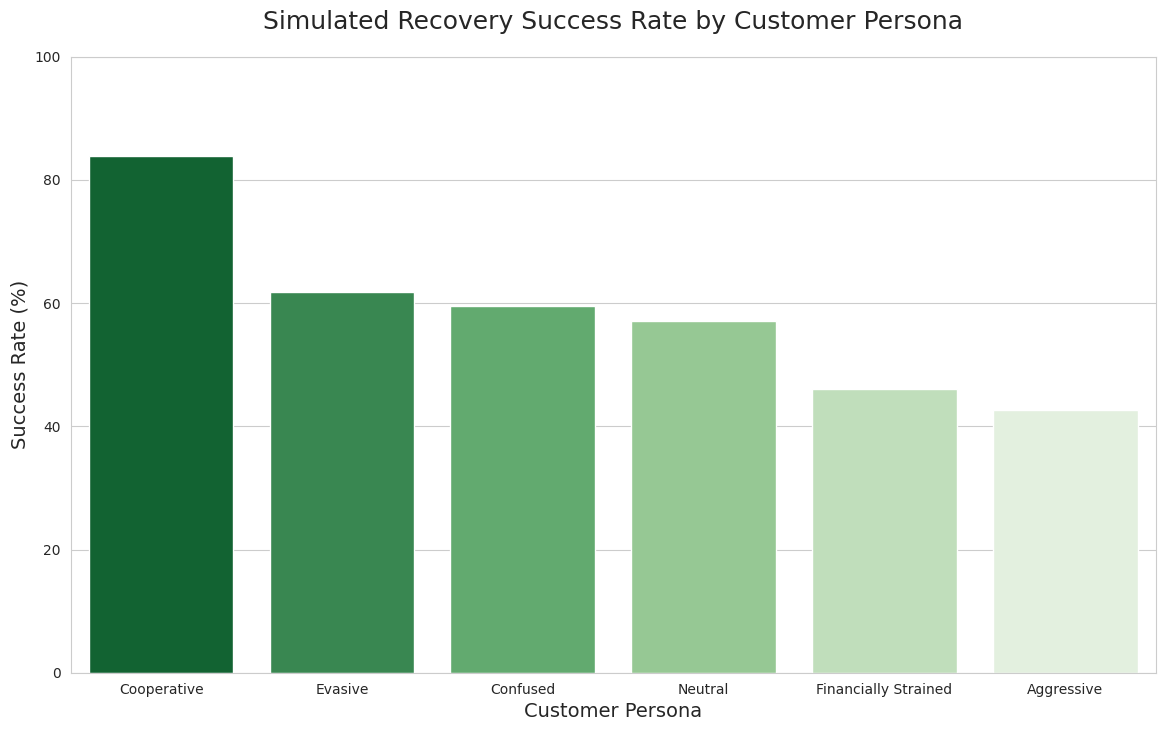

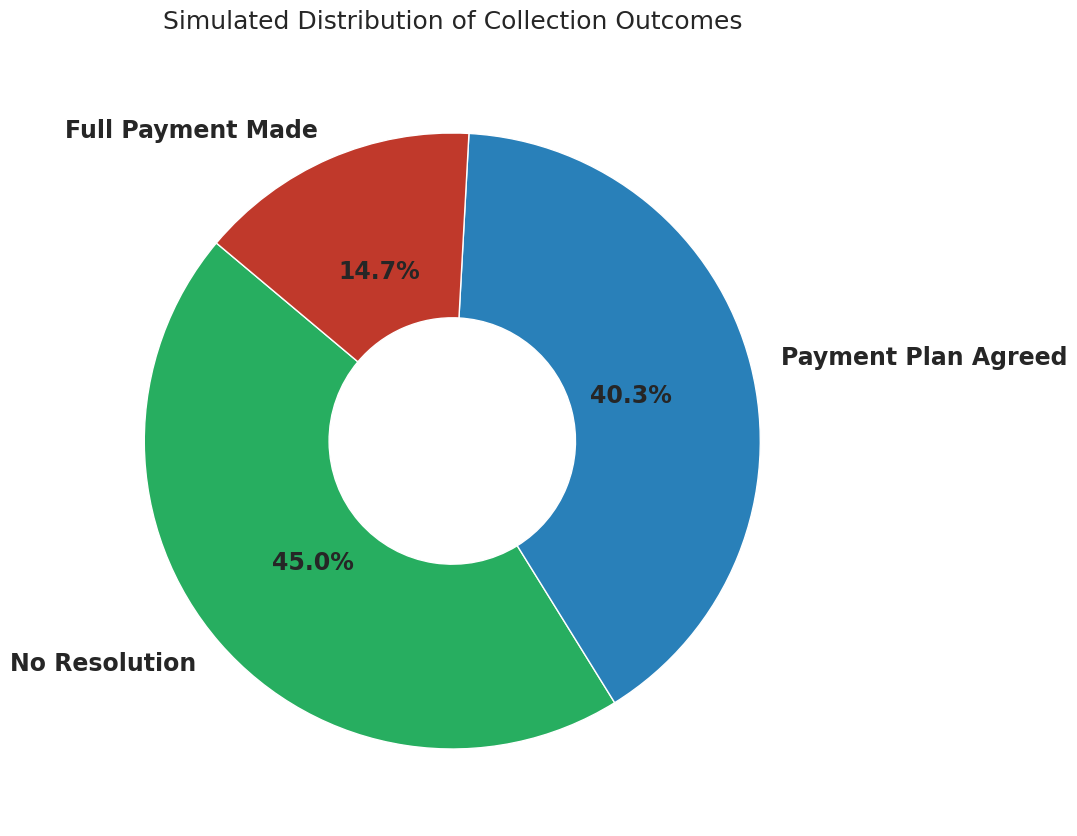

In [ ]:
# Post-Implementation Analysis Simulation
print("\n Simulating Post-Implementation Analysis")

# 1. Re-creating the fully enriched dataset ---
df_analysis = pd.read_csv('Analytics_loan_collection_dataset.csv')

# Applying Feature Engineering
df_analysis['TenureMonths'] = df_analysis['TenureMonths'].replace(0, 1)
df_analysis['PaymentCompliance'] = 1 - (df_analysis['MissedPayments'] / df_analysis['TenureMonths'])
df_analysis['InteractionRatio'] = df_analysis['InteractionAttempts'] / (df_analysis['TenureMonths'] + 1)
df_analysis['RiskScore'] = df_analysis['MissedPayments'] * df_analysis['DelaysDays'] * (1 + df_analysis['Complaints'])

# Applying Persona Classification
conditions = [
    (df_analysis['SentimentScore'] > 0.5) & (df_analysis['Complaints'] < 1) & (df_analysis['ResponseTimeHours'] < 24),
    (df_analysis['ResponseTimeHours'] > 48) & (df_analysis['InteractionAttempts'] > 5) & (df_analysis['AppUsageFrequency'] < 0.3),
    (df_analysis['SentimentScore'] < -0.5) | (df_analysis['Complaints'] > 2),
    (df_analysis['PartialPayments'] > 2) | (df_analysis['WebsiteVisits'] < 5),
    (df_analysis['EmploymentStatus'].isin(['Unemployed', 'Student'])) & (df_analysis['Income'] < 500000)
]
choices = ['Cooperative', 'Evasive', 'Aggressive', 'Confused', 'Financially Strained']
df_analysis['Persona'] = np.select(conditions, choices, default='Neutral')

# Loading the trained model to get probabilities
model = joblib.load('best_loan_default_model.pkl')
X_for_prediction = df_analysis.drop(['Target', 'CustomerID'], axis=1)
probabilities = model.predict_proba(X_for_prediction)[:, 1]
df_analysis['DefaultProbability'] = probabilities

print(" Enriched data for analysis has been successfully created.")

# 2. Run the simulation on the enriched data ---
np.random.seed(42)
customer_ids = df_analysis['CustomerID'].unique()
personas = df_analysis.set_index('CustomerID')['Persona']
risk_levels = df_analysis.set_index('CustomerID')['DefaultProbability'].apply(lambda x: 'High' if x > 0.7 else 'Medium' if x > 0.4 else 'Low')

simulated_data = []
for cid in customer_ids:
    persona = personas[cid]
    risk = risk_levels[cid]

    # Simulating outcome based on persona and risk
    success_prob = 0.6 # Base success
    if persona == 'Cooperative': success_prob += 0.25
    if persona == 'Financially Strained': success_prob -= 0.1
    if persona == 'Aggressive': success_prob -= 0.2
    if risk == 'Low': success_prob += 0.1
    if risk == 'High': success_prob -= 0.15

    # Ensuring probabilities sum to 1
    p_plan = 0.4
    p_full = max(0, success_prob - p_plan)
    p_no_res = max(0, 1 - (p_plan + p_full))
    p_final = [p_plan, p_full, p_no_res]
    p_final = [p / sum(p_final) for p in p_final] # Normalize

    outcome = np.random.choice(
        ['Payment Plan Agreed', 'Full Payment Made', 'No Resolution'],
        p=p_final
    )

    simulated_data.append({
        'CustomerID': cid,
        'Persona': persona,
        'RiskLevel': risk,
        'Outcome': outcome
    })

results_df = pd.DataFrame(simulated_data)
print(" Simulation of collection outcomes is complete.")

# 3. Visualize the simulated results

# Visualization 1: Recovery Rate by Persona
plt.figure(figsize=(14, 8))
recovery_by_persona = results_df[results_df['Outcome'] != 'No Resolution'].groupby('Persona').size() / results_df.groupby('Persona').size() * 100
recovery_by_persona = recovery_by_persona.sort_values(ascending=False)

sns.barplot(x=recovery_by_persona.index, y=recovery_by_persona.values, palette='Greens_r')
plt.title('Simulated Recovery Success Rate by Customer Persona', fontsize=18, pad=20)
plt.xlabel('Customer Persona', fontsize=14)
plt.ylabel('Success Rate (%)', fontsize=14)
plt.ylim(0, 100)
plt.show()


# Visualization 2: Distribution of Collection Outcomes (Donut Chart)
outcome_counts = results_df['Outcome'].value_counts()
colors = ['#27ae60', '#2980b9', '#c0392b']

plt.figure(figsize=(10, 10))
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140,
        wedgeprops=dict(width=0.6, edgecolor='w'), textprops={'fontsize': 17, 'fontweight': 'bold'}, colors=colors)
plt.title('Simulated Distribution of Collection Outcomes', fontsize=18, pad=20)
plt.show()

# **Thankyou TVS Credit Analytics team!**